# SisFall — Random Falls Gallery

Randomly samples **20 fall recordings** from different participants and plots the ADXL345 accelerometer (X, Y, Z) for each one in a single tall figure.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

SISFALL_PATH = 'SisFall_dataset'
ADXL_SCALE   = (2 * 16) / (2**13)   # g per bit

FALL_DESC = {
    'F01': 'Forward fall — slip',
    'F02': 'Backward fall — slip',
    'F03': 'Lateral fall — slip',
    'F04': 'Forward fall — trip',
    'F05': 'Forward fall jogging — trip',
    'F06': 'Vertical fall — faint',
    'F07': 'Forward + table brace — faint',
    'F08': 'Forward fall getting up',
    'F09': 'Lateral fall getting up',
    'F10': 'Forward fall sitting down',
    'F11': 'Backward fall sitting down',
    'F12': 'Lateral fall sitting down',
    'F13': 'Forward fall while seated — faint',
    'F14': 'Backward fall while seated — faint',
    'F15': 'Lateral fall while seated — faint',
}

print('Setup done.')

Setup done.


In [2]:
def load_adxl(filepath):
    """Read a SisFall .txt file and return ADXL345 X/Y/Z in g as a (N, 3) float array."""
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip().rstrip(';')
            if not line:
                continue
            try:
                parts = [int(x.strip()) for x in line.split(',')]
                if len(parts) == 9:
                    rows.append(parts[:3])   # cols 0-2: ADXL_X, ADXL_Y, ADXL_Z
            except ValueError:
                pass
    return np.array(rows, dtype=np.float32) * ADXL_SCALE  # convert to g


# Collect all fall files across every subject
all_fall_files = []
for subj in sorted(os.listdir(SISFALL_PATH)):
    subj_path = os.path.join(SISFALL_PATH, subj)
    if not os.path.isdir(subj_path):
        continue
    for fname in os.listdir(subj_path):
        if fname.endswith('.txt') and fname.startswith('F'):
            all_fall_files.append(os.path.join(subj_path, fname))

print(f'Total fall files found: {len(all_fall_files)}')

Total fall files found: 1798


In [3]:
# --- parameters ---
N_PLOTS = 20
SEED    = 42          # change to get a different random selection

random.seed(SEED)
chosen = random.sample(all_fall_files, N_PLOTS)
chosen.sort()         # sort for readability in the figure

print('Selected files:')
for p in chosen:
    print(' ', os.path.relpath(p, SISFALL_PATH))

Selected files:
  SA01/F05_SA01_R02.txt
  SA01/F05_SA01_R05.txt
  SA01/F07_SA01_R01.txt
  SA03/F06_SA03_R02.txt
  SA03/F07_SA03_R03.txt
  SA03/F12_SA03_R01.txt
  SA04/F10_SA04_R04.txt
  SA04/F14_SA04_R04.txt
  SA06/F11_SA06_R04.txt
  SA07/F01_SA07_R03.txt
  SA07/F13_SA07_R01.txt
  SA08/F04_SA08_R04.txt
  SA12/F14_SA12_R02.txt
  SA15/F02_SA15_R03.txt
  SA17/F14_SA17_R03.txt
  SA18/F13_SA18_R04.txt
  SA19/F15_SA19_R04.txt
  SA21/F04_SA21_R03.txt
  SA21/F07_SA21_R01.txt
  SA21/F09_SA21_R01.txt


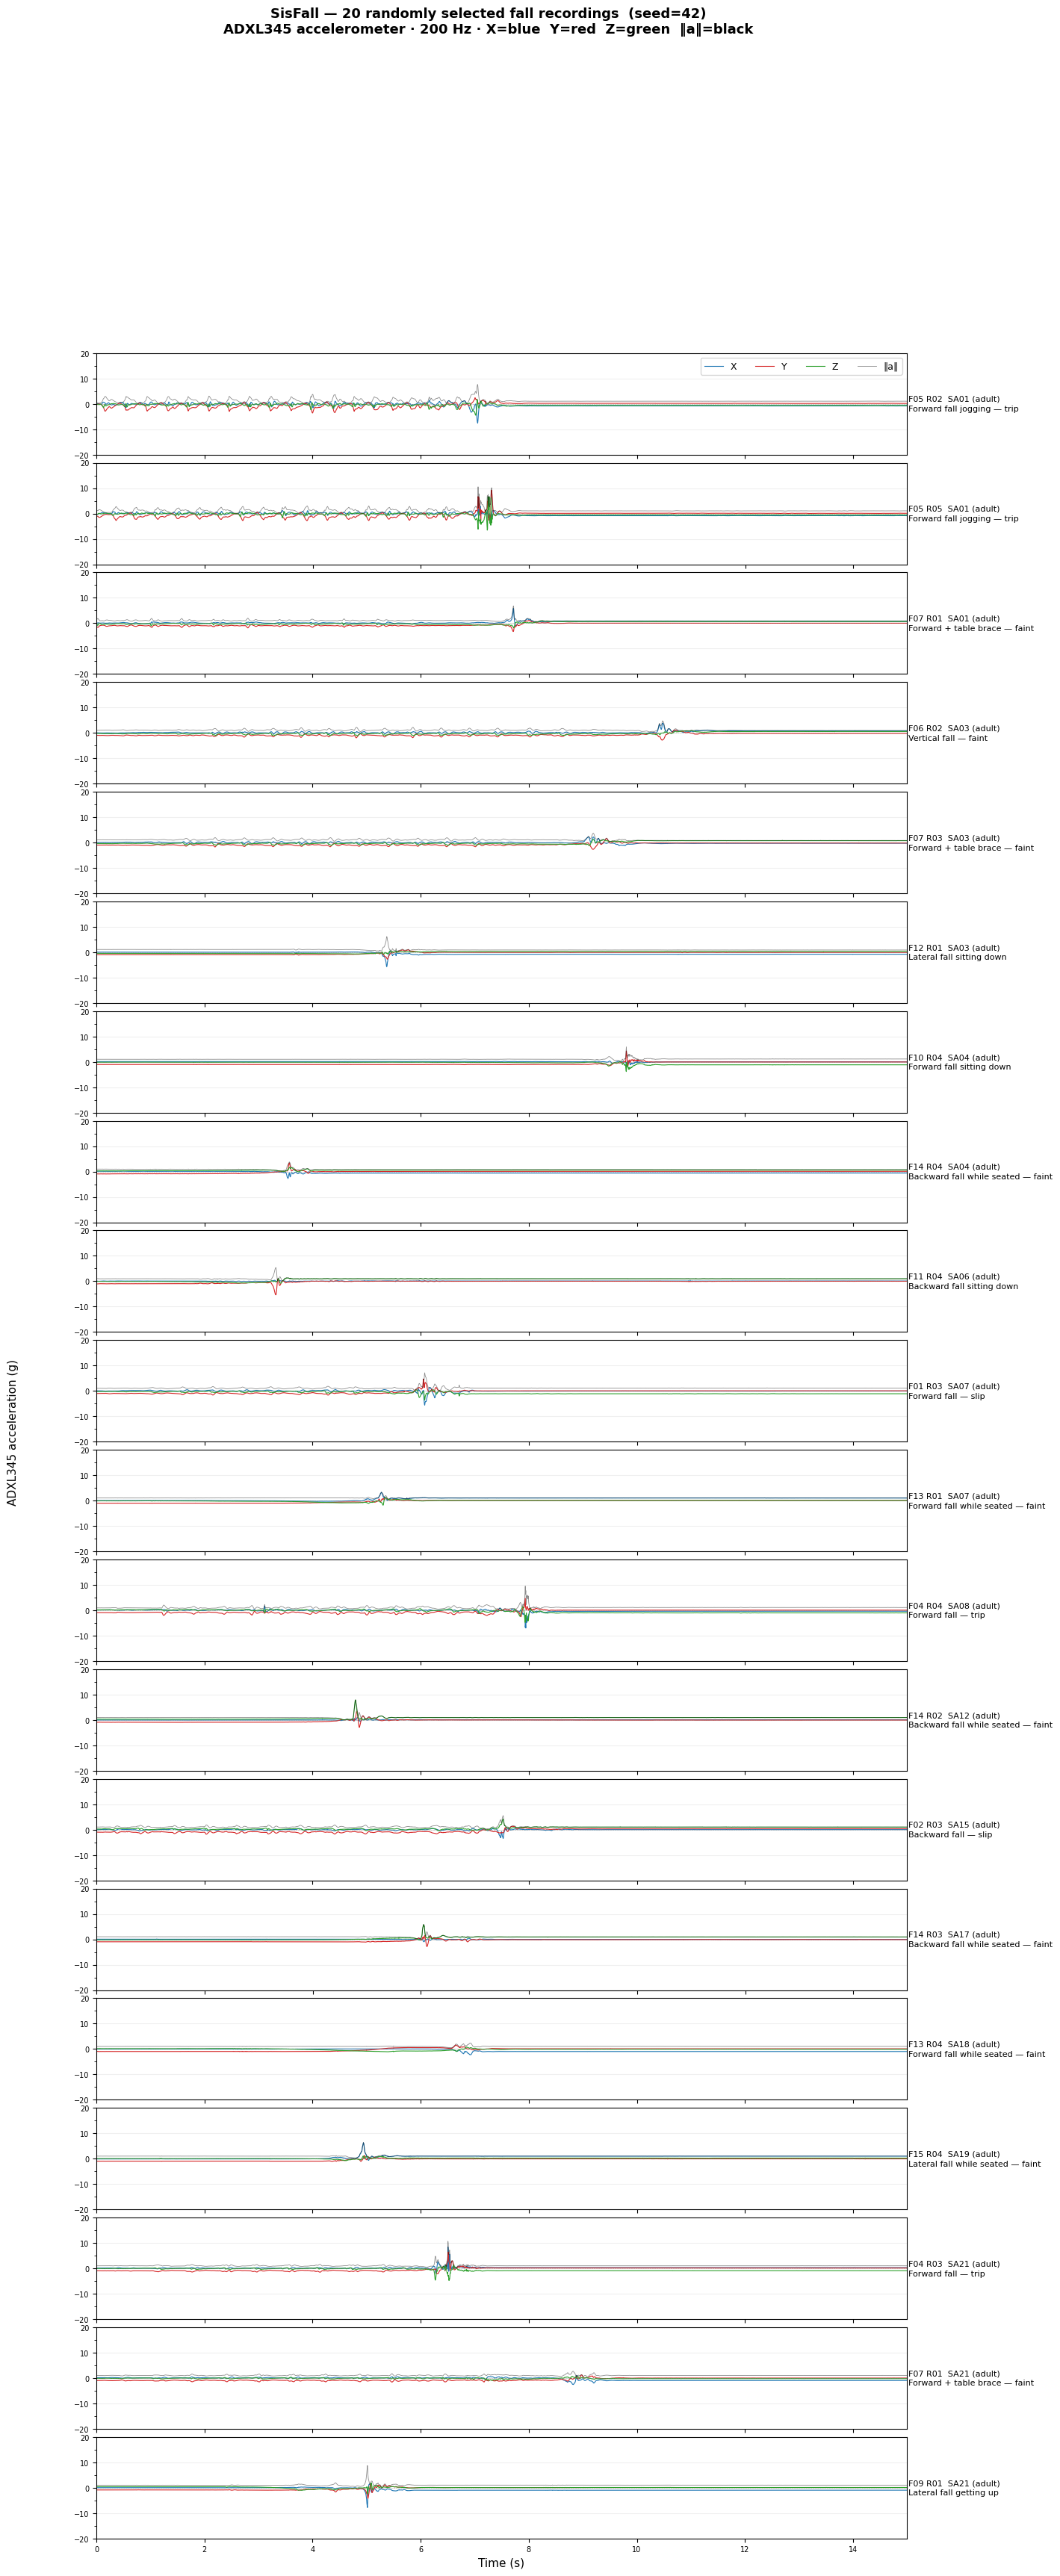

Saved signals_png/sisfall_falls_gallery.png


In [4]:
AXIS_COLORS = ['#1f77b4', '#d62728', '#2ca02c']   # blue=X, red=Y, green=Z

fig, axes = plt.subplots(
    N_PLOTS, 1,
    figsize=(14, N_PLOTS * 1.9),
    gridspec_kw={'hspace': 0.08},
)

for ax, fpath in zip(axes, chosen):
    fname   = os.path.basename(fpath)
    parts   = fname.replace('.txt', '').split('_')
    code, subj, trial = parts[0], parts[1], parts[2]
    desc    = FALL_DESC.get(code, code)
    group   = 'adult' if subj.startswith('SA') else 'elderly'

    acc = load_adxl(fpath)             # (N, 3)  in g
    t   = np.arange(len(acc)) / 200.0  # time in seconds @ 200 Hz

    for i, (axis_name, color) in enumerate(zip(['X', 'Y', 'Z'], AXIS_COLORS)):
        ax.plot(t, acc[:, i], color=color, linewidth=0.8,
                label=axis_name if ax is axes[0] else None)

    # vector magnitude as a thin black line
    mag = np.linalg.norm(acc, axis=1)
    ax.plot(t, mag, color='black', linewidth=0.6, alpha=0.45,
            label='‖a‖' if ax is axes[0] else None)

    ax.axhline(0, color='grey', linewidth=0.4, linestyle=':')
    ax.set_xlim(0, t[-1])
    ax.set_ylim(-20, 20)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(True, axis='y', alpha=0.2)

    # label on the right side
    label_text = f'{code} {trial}  {subj} ({group})\n{desc}'
    ax.text(1.002, 0.5, label_text,
            transform=ax.transAxes,
            va='center', ha='left',
            fontsize=8, linespacing=1.4)

    # hide x tick labels for all but the last panel
    if ax is not axes[-1]:
        ax.set_xticklabels([])

axes[-1].set_xlabel('Time (s)', fontsize=11)

# shared y label
fig.text(0.04, 0.5, 'ADXL345 acceleration (g)', va='center',
         rotation='vertical', fontsize=11)

# legend at the top
axes[0].legend(loc='upper right', fontsize=9, ncol=4, framealpha=0.8)

fig.suptitle(
    f'SisFall — {N_PLOTS} randomly selected fall recordings  (seed={SEED})\n'
    'ADXL345 accelerometer · 200 Hz · X=blue  Y=red  Z=green  ‖a‖=black',
    fontsize=13, fontweight='bold', y=1.002
)

os.makedirs('signals_png', exist_ok=True)
plt.savefig('signals_png/sisfall_falls_gallery.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved signals_png/sisfall_falls_gallery.png')

---
## Per-class galleries — one figure for each of the 15 fall types

Each figure below shows up to 20 randomly sampled recordings **from that specific fall class**, drawn from all available subjects and trials.

In [5]:
def plot_fall_class(code, files_for_code, n_plots=20, seed=42, save=True):
    """Plot up to n_plots randomly chosen recordings for a single fall class."""
    random.seed(seed)
    pool = sorted(files_for_code)
    chosen = random.sample(pool, min(n_plots, len(pool)))
    chosen.sort()

    n = len(chosen)
    fig, axes = plt.subplots(
        n, 1,
        figsize=(14, n * 1.9),
        gridspec_kw={'hspace': 0.08},
    )
    if n == 1:
        axes = [axes]

    desc = FALL_DESC.get(code, code)

    for ax, fpath in zip(axes, chosen):
        fname = os.path.basename(fpath)
        parts = fname.replace('.txt', '').split('_')
        _, subj, trial = parts[0], parts[1], parts[2]
        group = 'adult' if subj.startswith('SA') else 'elderly'

        acc = load_adxl(fpath)
        t   = np.arange(len(acc)) / 200.0

        for i, (axis_name, color) in enumerate(zip(['X', 'Y', 'Z'], AXIS_COLORS)):
            ax.plot(t, acc[:, i], color=color, linewidth=0.8,
                    label=axis_name if ax is axes[0] else None)

        mag = np.linalg.norm(acc, axis=1)
        ax.plot(t, mag, color='black', linewidth=0.6, alpha=0.45,
                label='‖a‖' if ax is axes[0] else None)

        ax.axhline(0, color='grey', linewidth=0.4, linestyle=':')
        ax.set_xlim(0, t[-1])
        ax.set_ylim(-20, 20)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))
        ax.tick_params(axis='y', labelsize=7)
        ax.tick_params(axis='x', labelsize=7)
        ax.grid(True, axis='y', alpha=0.2)

        label_text = f'{trial}  {subj} ({group})'
        ax.text(1.002, 0.5, label_text,
                transform=ax.transAxes,
                va='center', ha='left',
                fontsize=8.5)

        if ax is not axes[-1]:
            ax.set_xticklabels([])

    axes[-1].set_xlabel('Time (s)', fontsize=11)
    fig.text(0.04, 0.5, 'ADXL345 acceleration (g)', va='center',
             rotation='vertical', fontsize=11)
    axes[0].legend(loc='upper right', fontsize=9, ncol=4, framealpha=0.8)

    fig.suptitle(
        f'{code} — {desc}\n'
        f'{n} randomly sampled recordings (seed={seed})  ·  '
        'X=blue  Y=red  Z=green  ‖a‖=black',
        fontsize=13, fontweight='bold', y=1.002
    )

    if save:
        fname_out = f'/home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_{code}.png'
        plt.savefig(fname_out, dpi=120, bbox_inches='tight')
        print(f'Saved {fname_out}')

    plt.show()


# Build a dict: fall code → list of file paths
from collections import defaultdict
files_by_code = defaultdict(list)
for fpath in all_fall_files:
    code = os.path.basename(fpath).split('_')[0]
    files_by_code[code].append(fpath)

for code in sorted(files_by_code):
    n_available = len(files_by_code[code])
    print(f'{code}: {n_available} files  ({FALL_DESC.get(code, "")})')

F01: 119 files  (Forward fall — slip)
F02: 120 files  (Backward fall — slip)
F03: 120 files  (Lateral fall — slip)
F04: 120 files  (Forward fall — trip)
F05: 120 files  (Forward fall jogging — trip)
F06: 120 files  (Vertical fall — faint)
F07: 120 files  (Forward + table brace — faint)
F08: 120 files  (Forward fall getting up)
F09: 120 files  (Lateral fall getting up)
F10: 119 files  (Forward fall sitting down)
F11: 120 files  (Backward fall sitting down)
F12: 120 files  (Lateral fall sitting down)
F13: 120 files  (Forward fall while seated — faint)
F14: 120 files  (Backward fall while seated — faint)
F15: 120 files  (Lateral fall while seated — faint)


Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F01.png


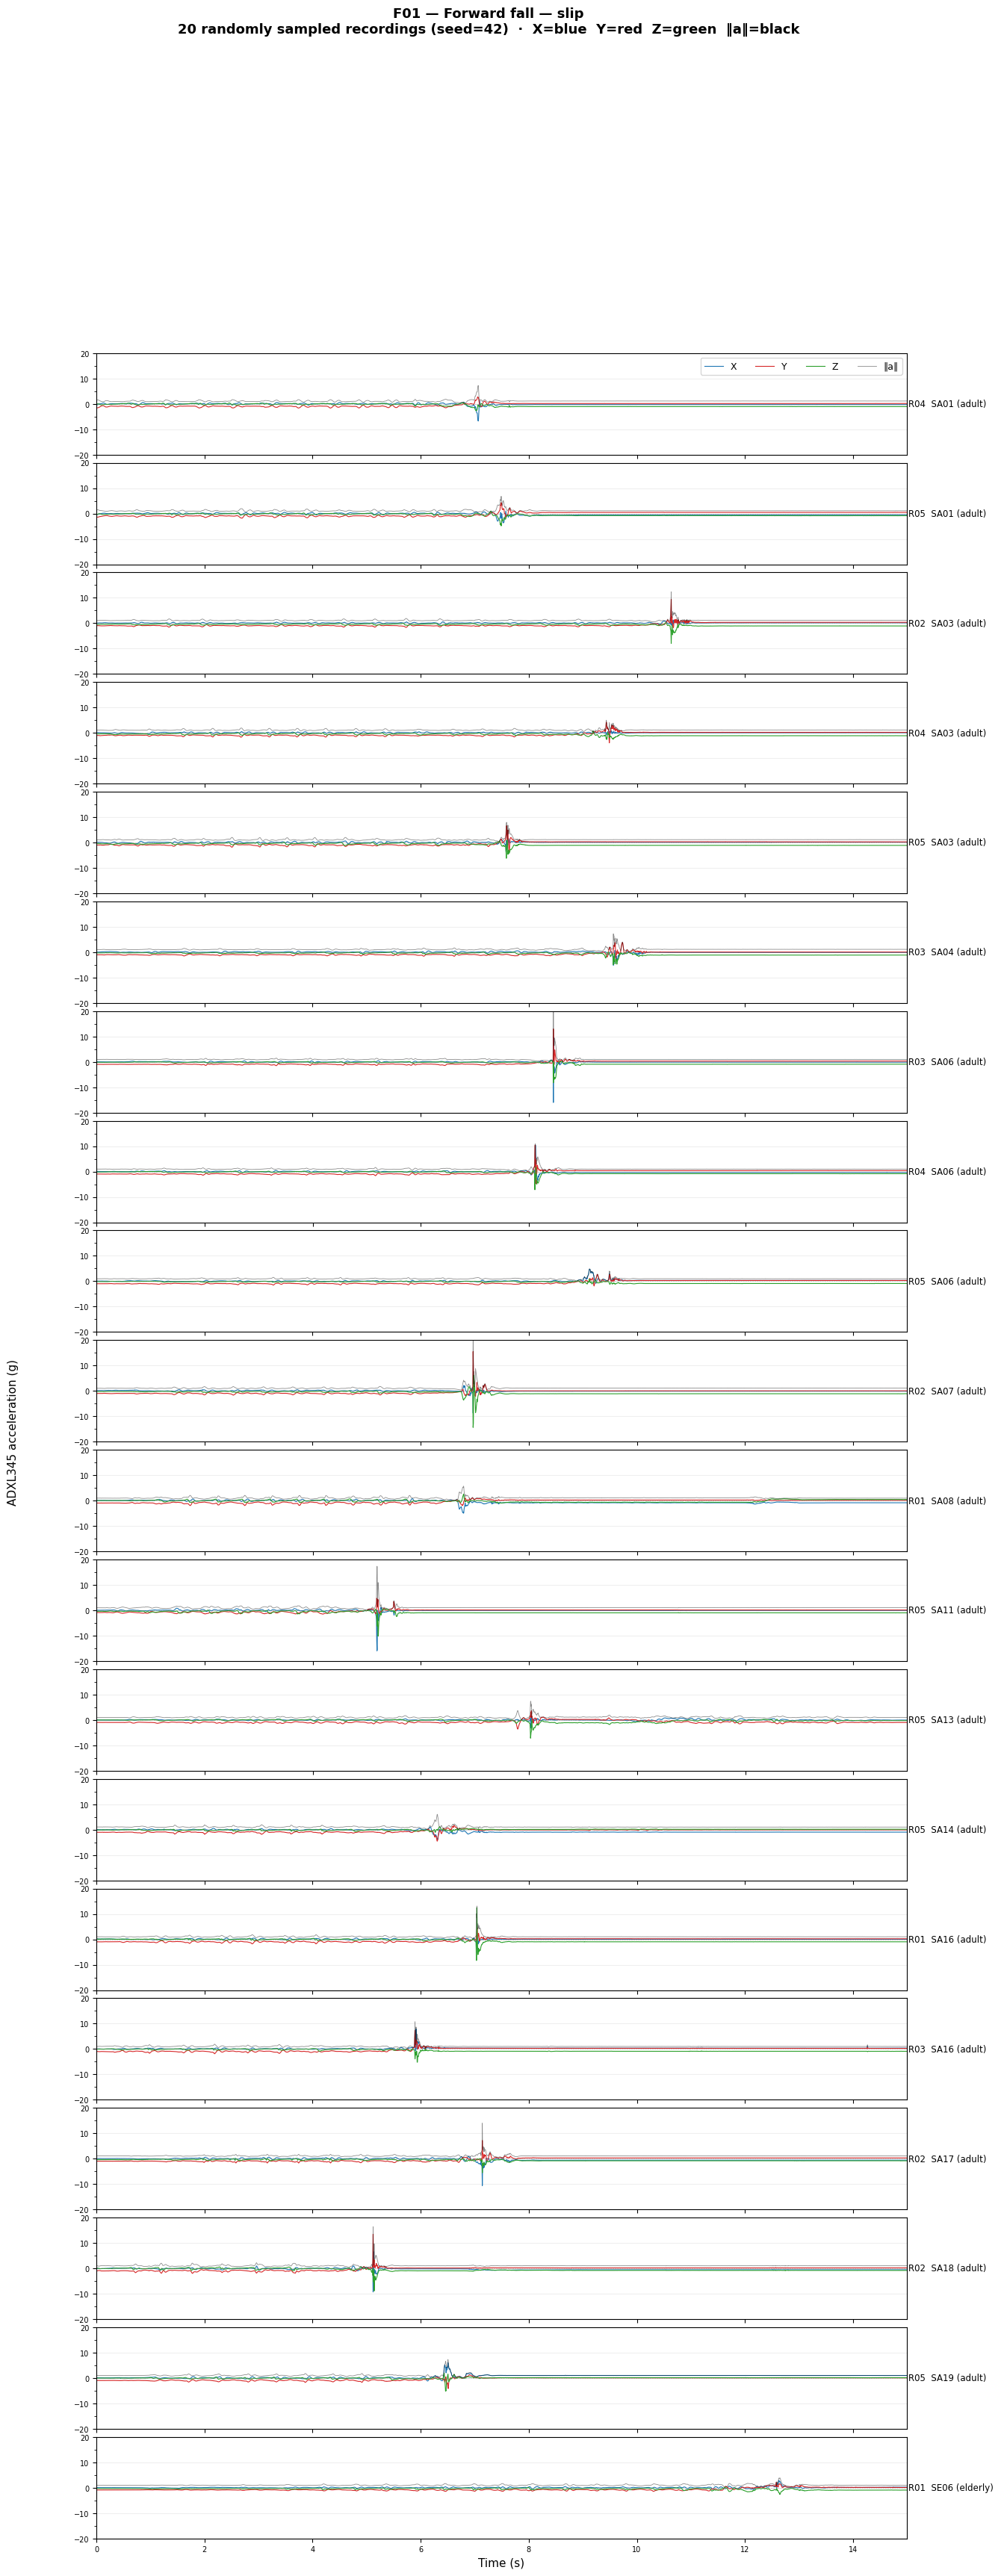

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F02.png


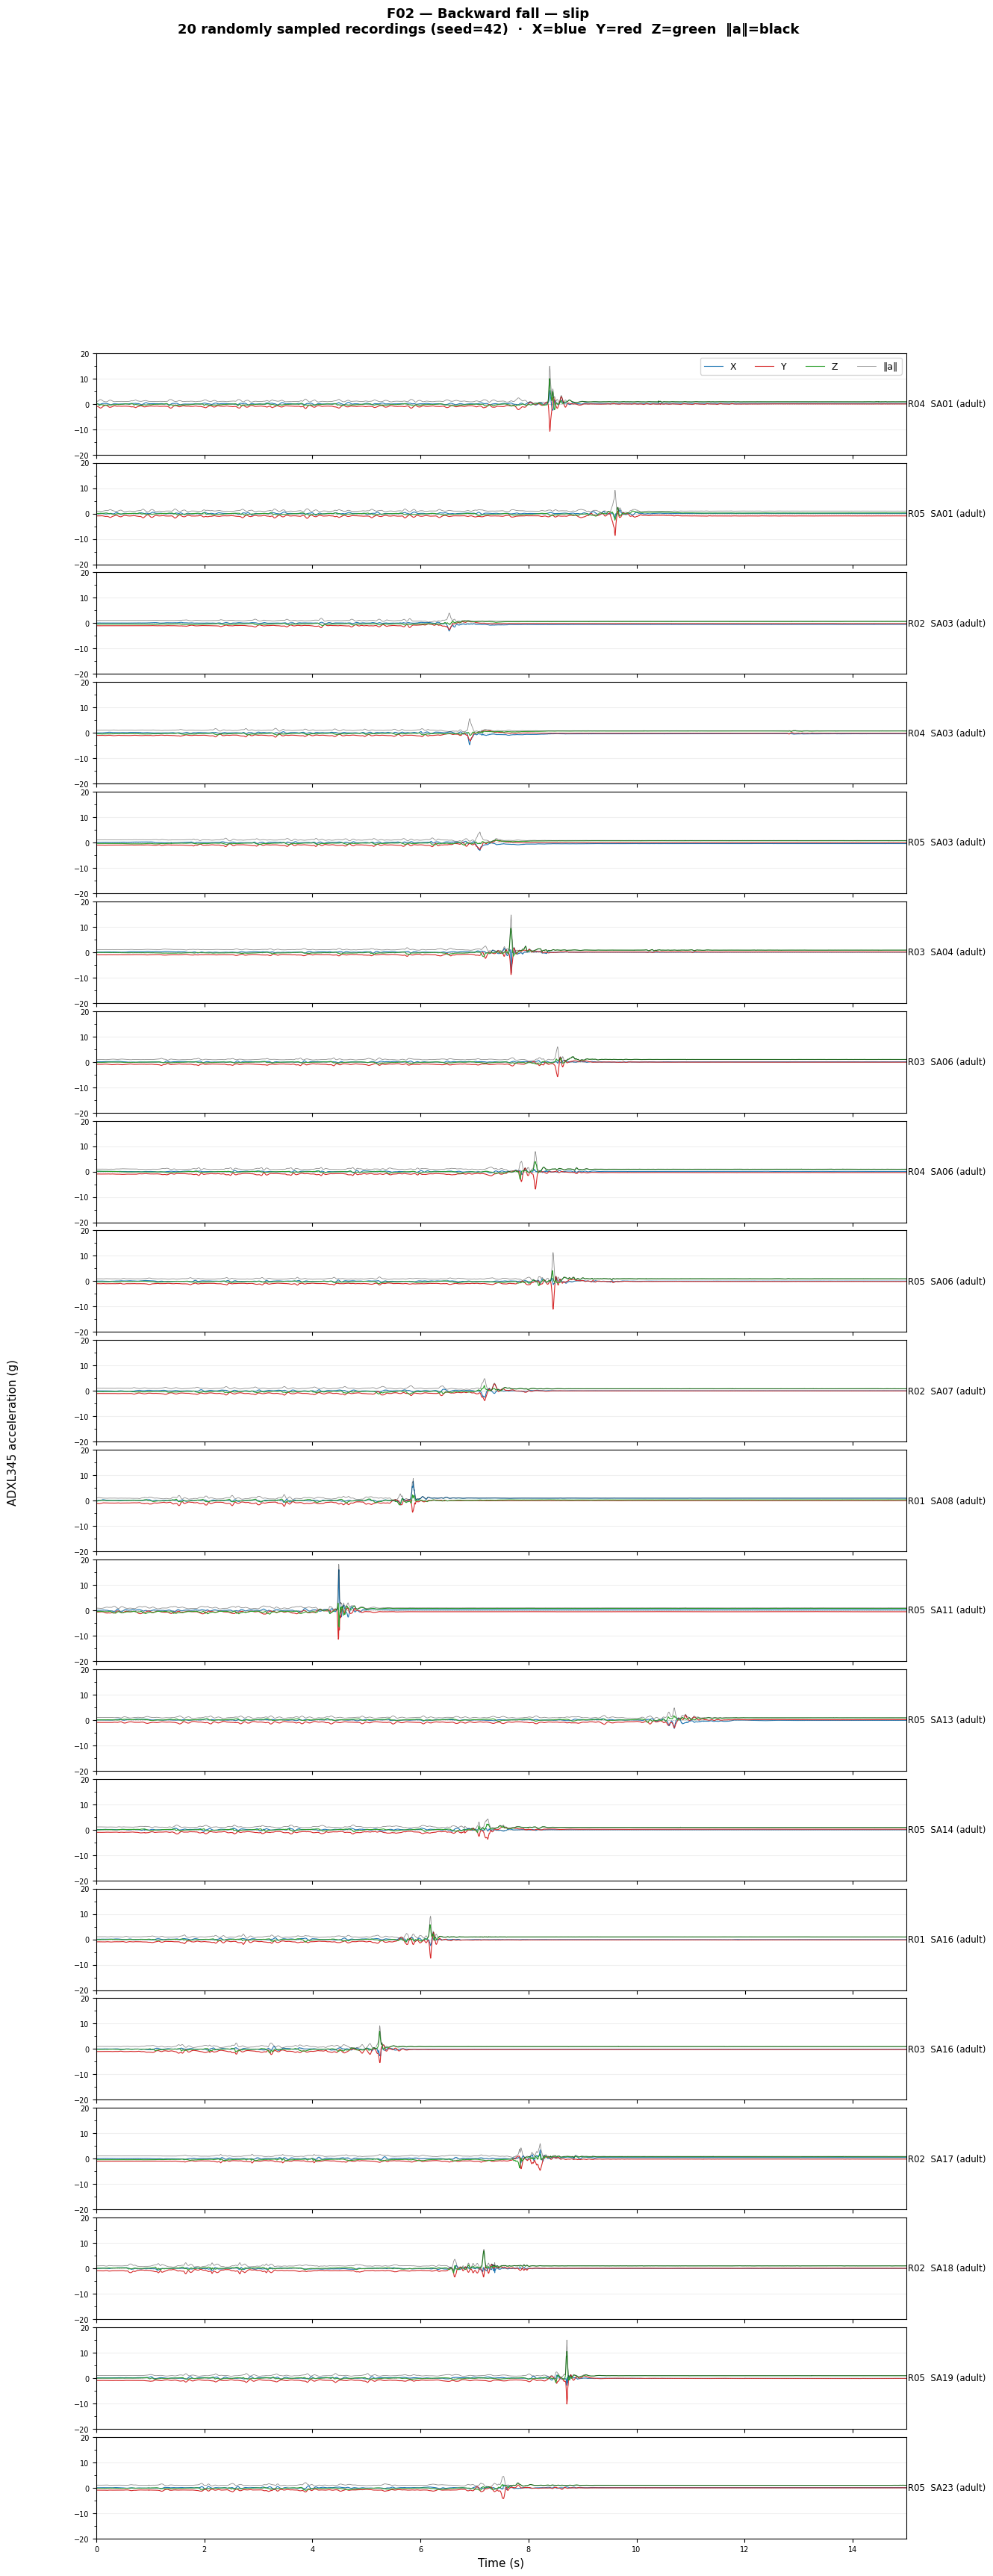

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F03.png


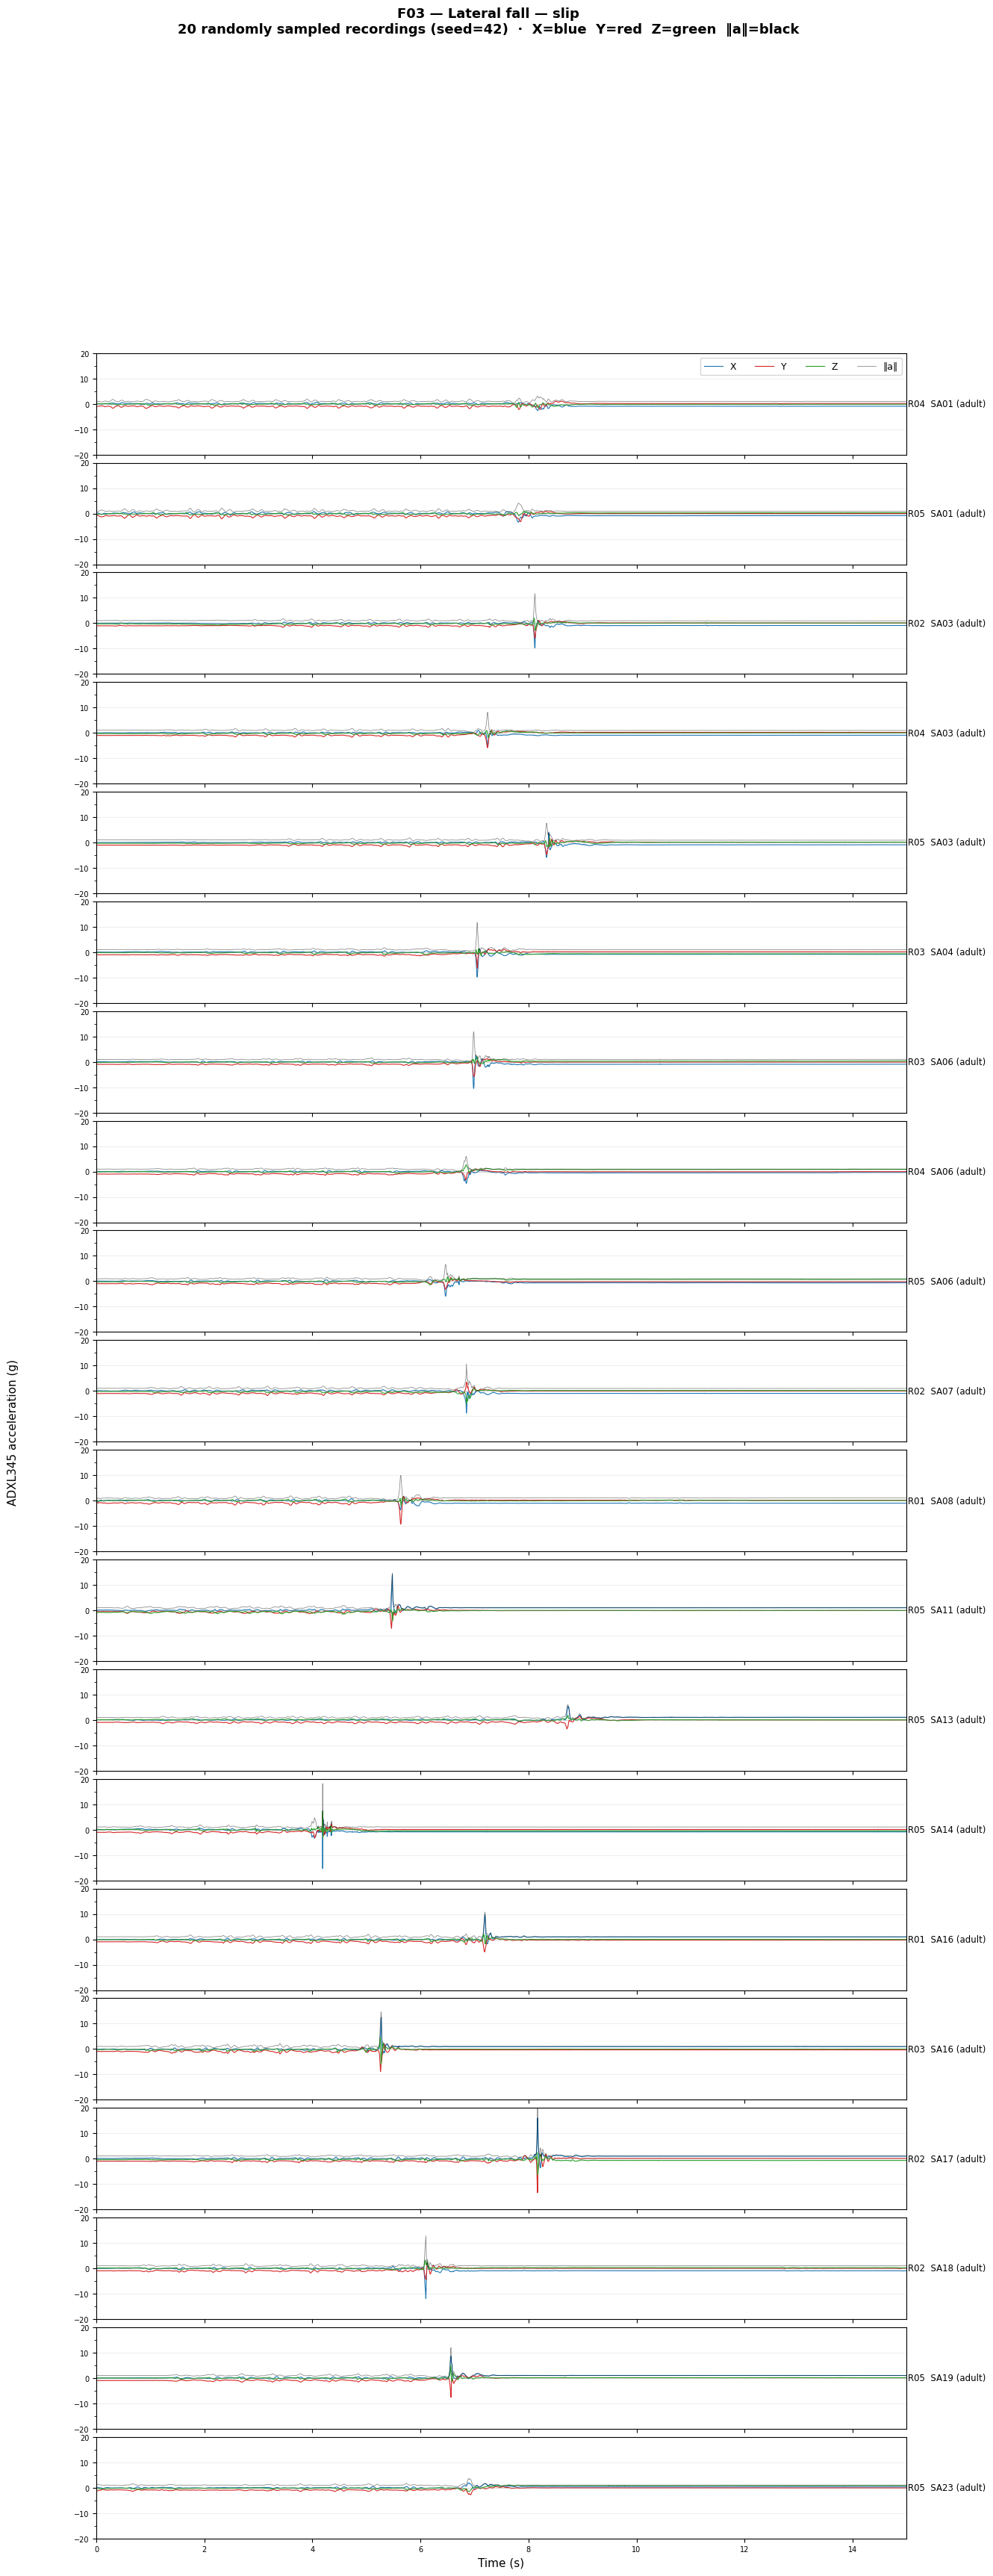

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F04.png


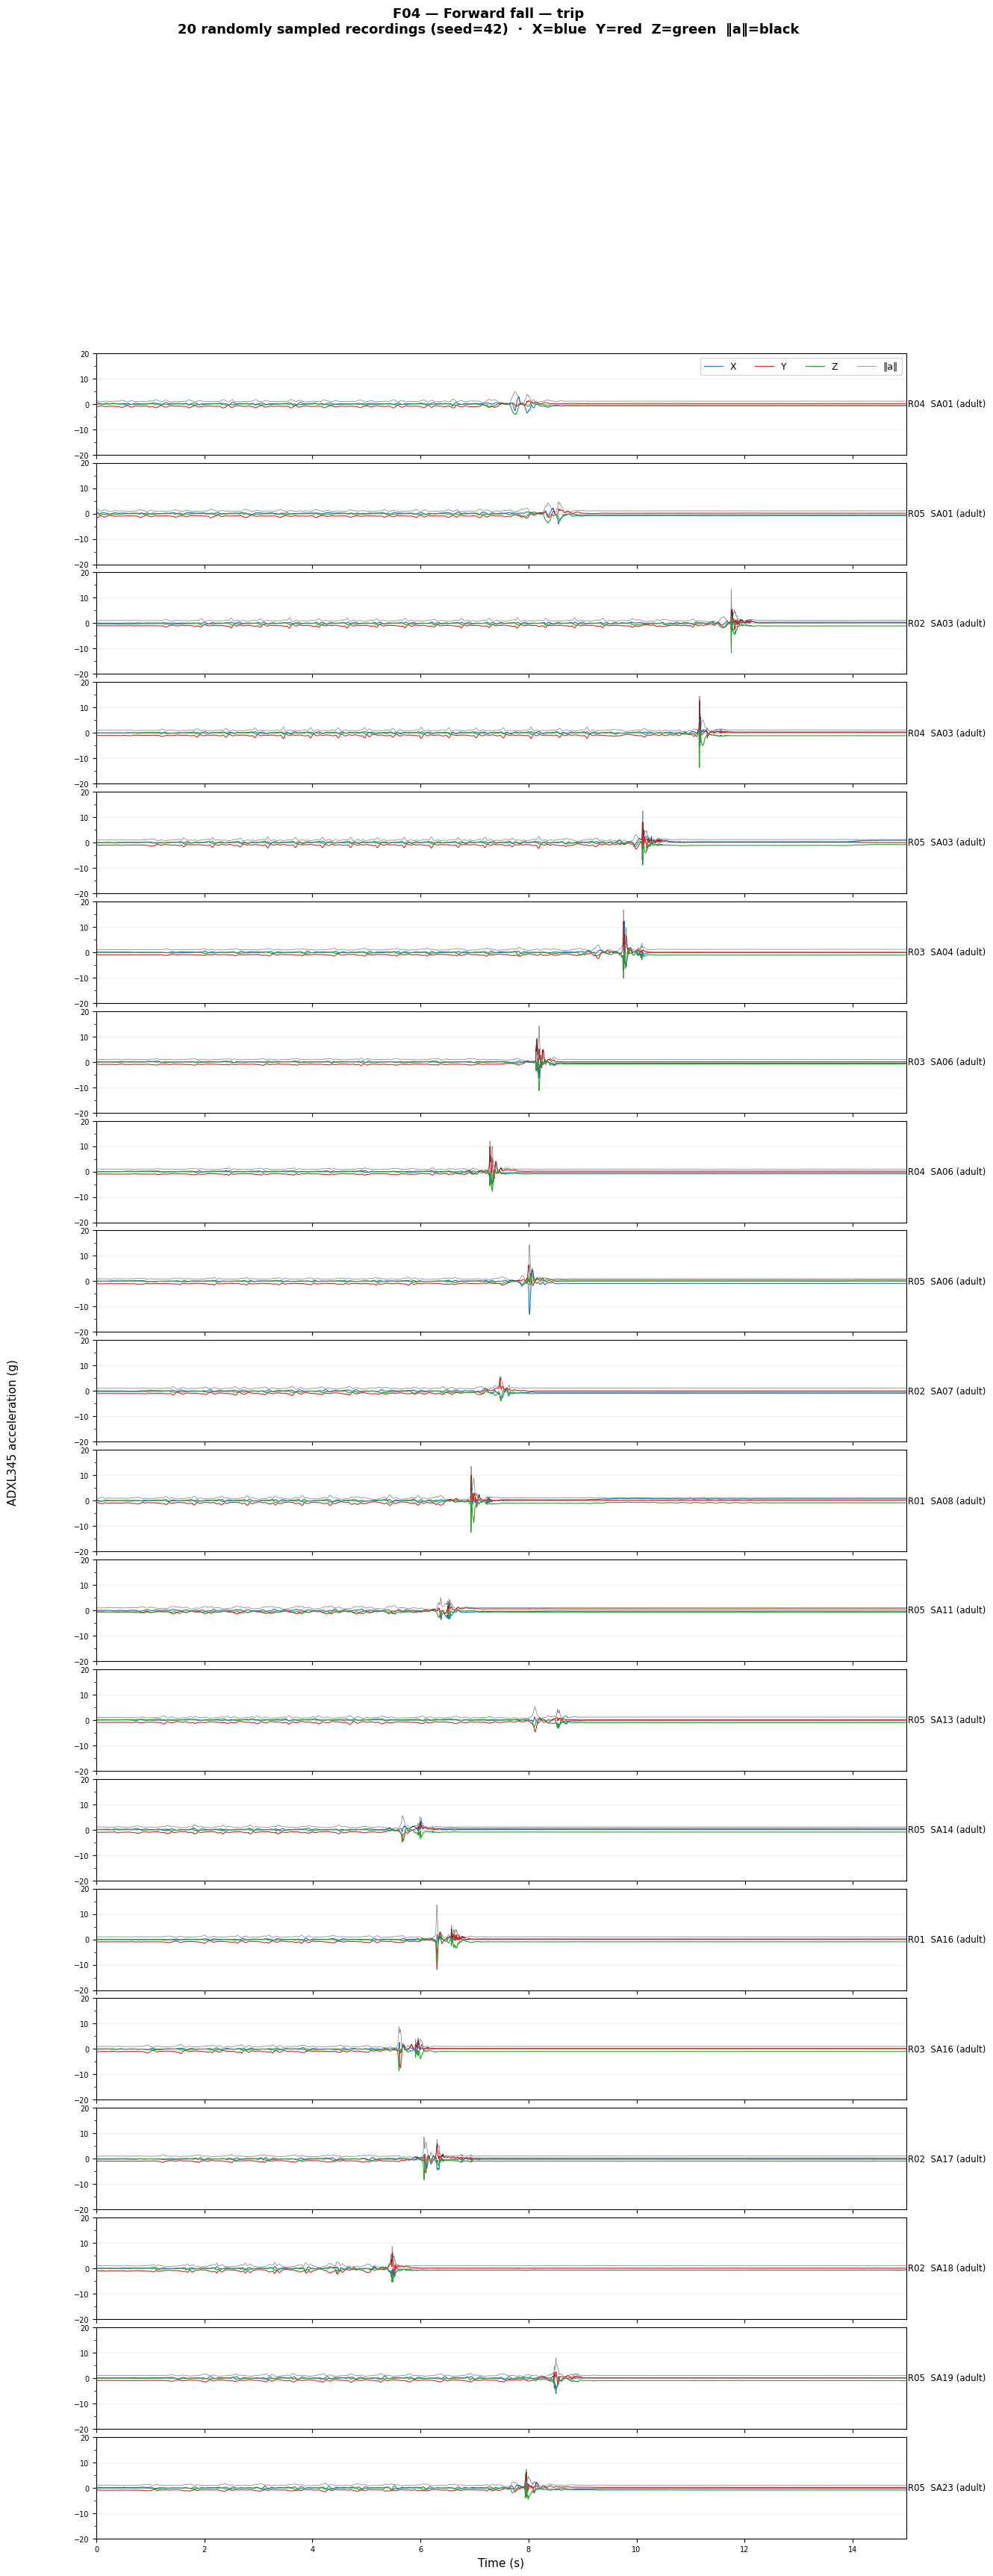

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F05.png


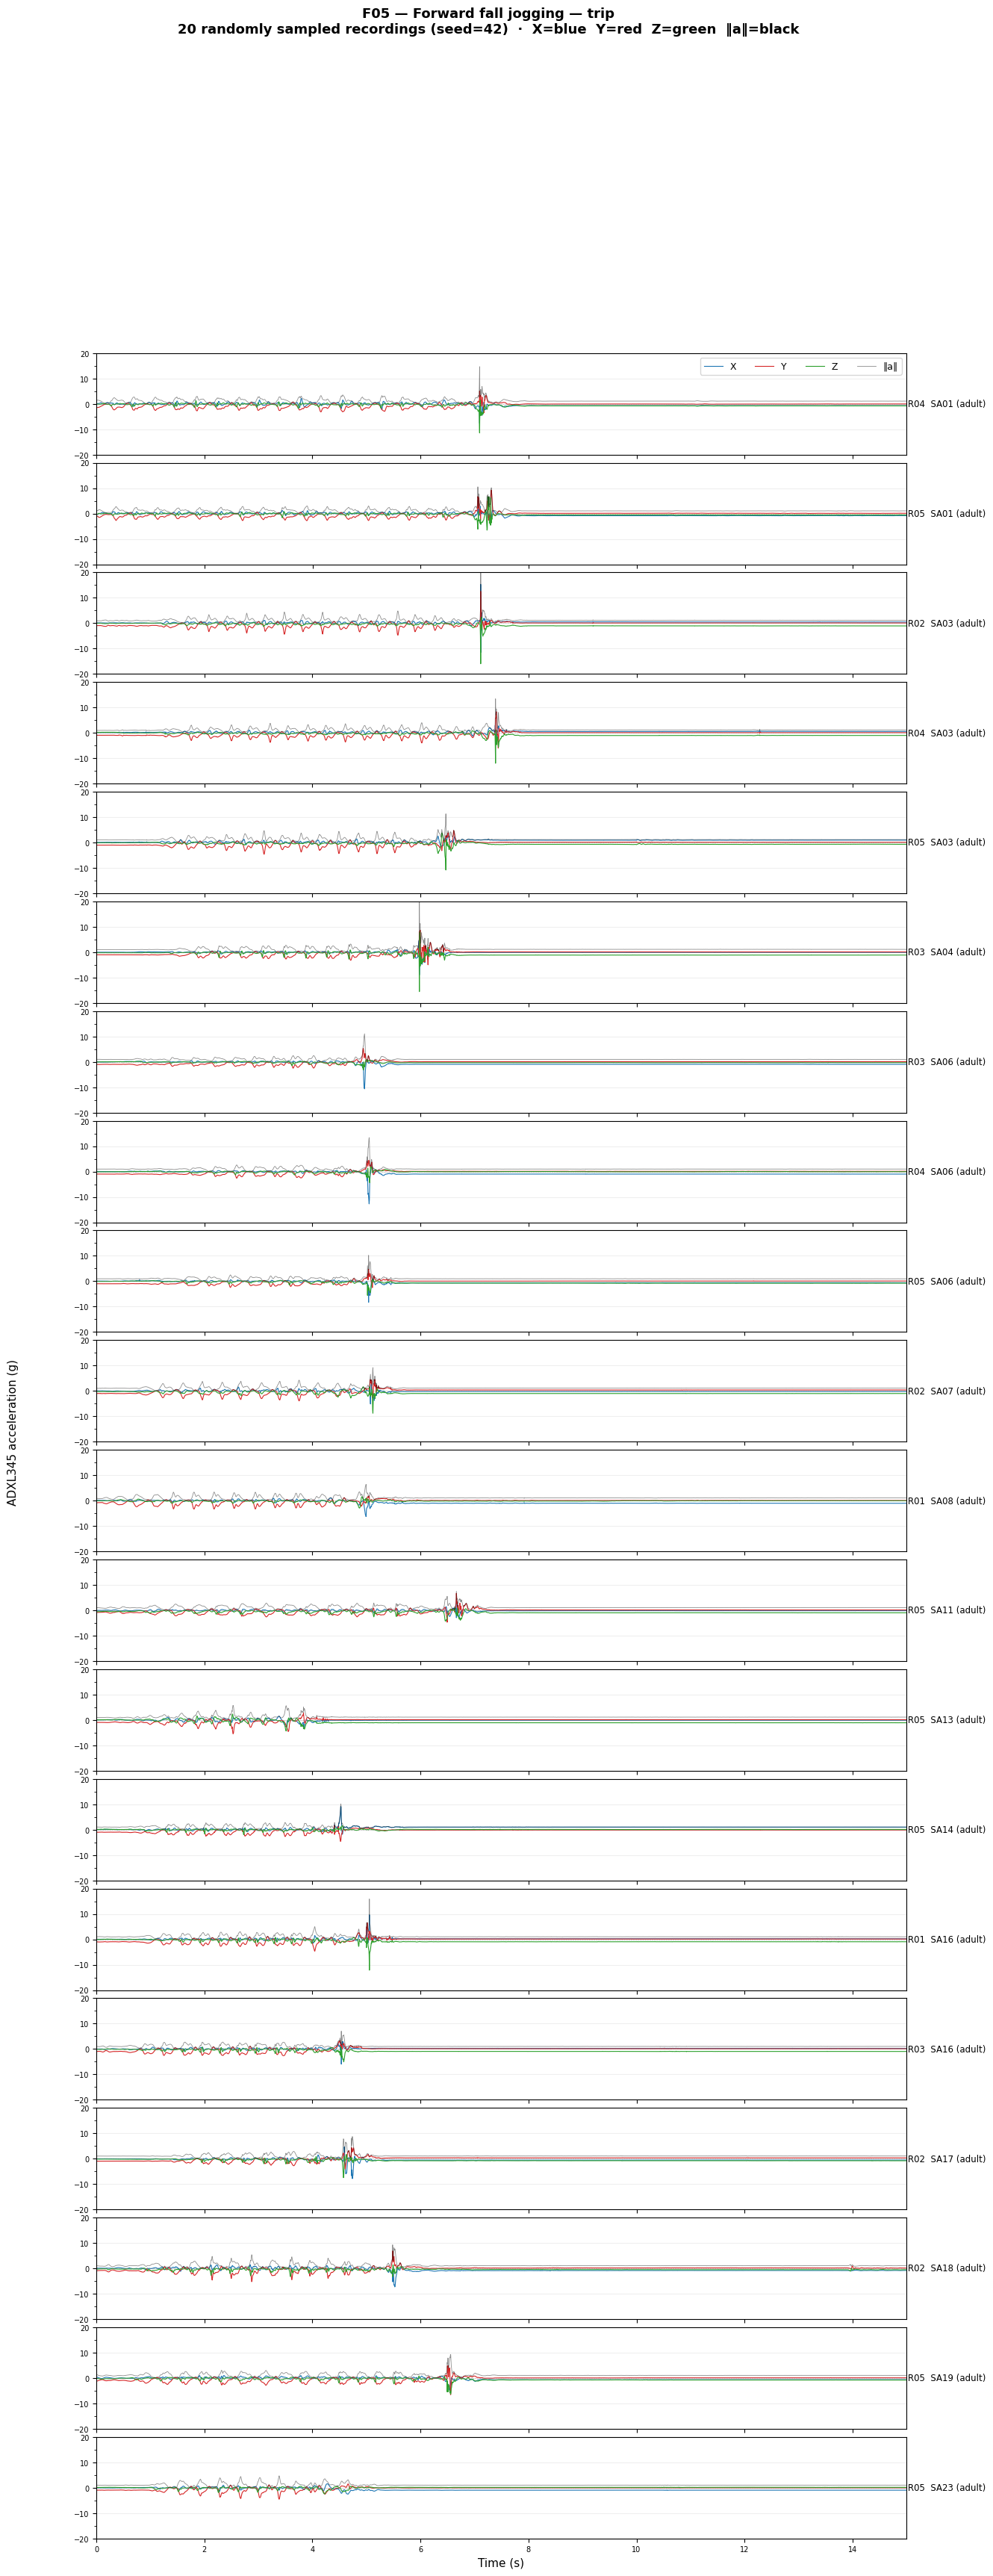

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F06.png


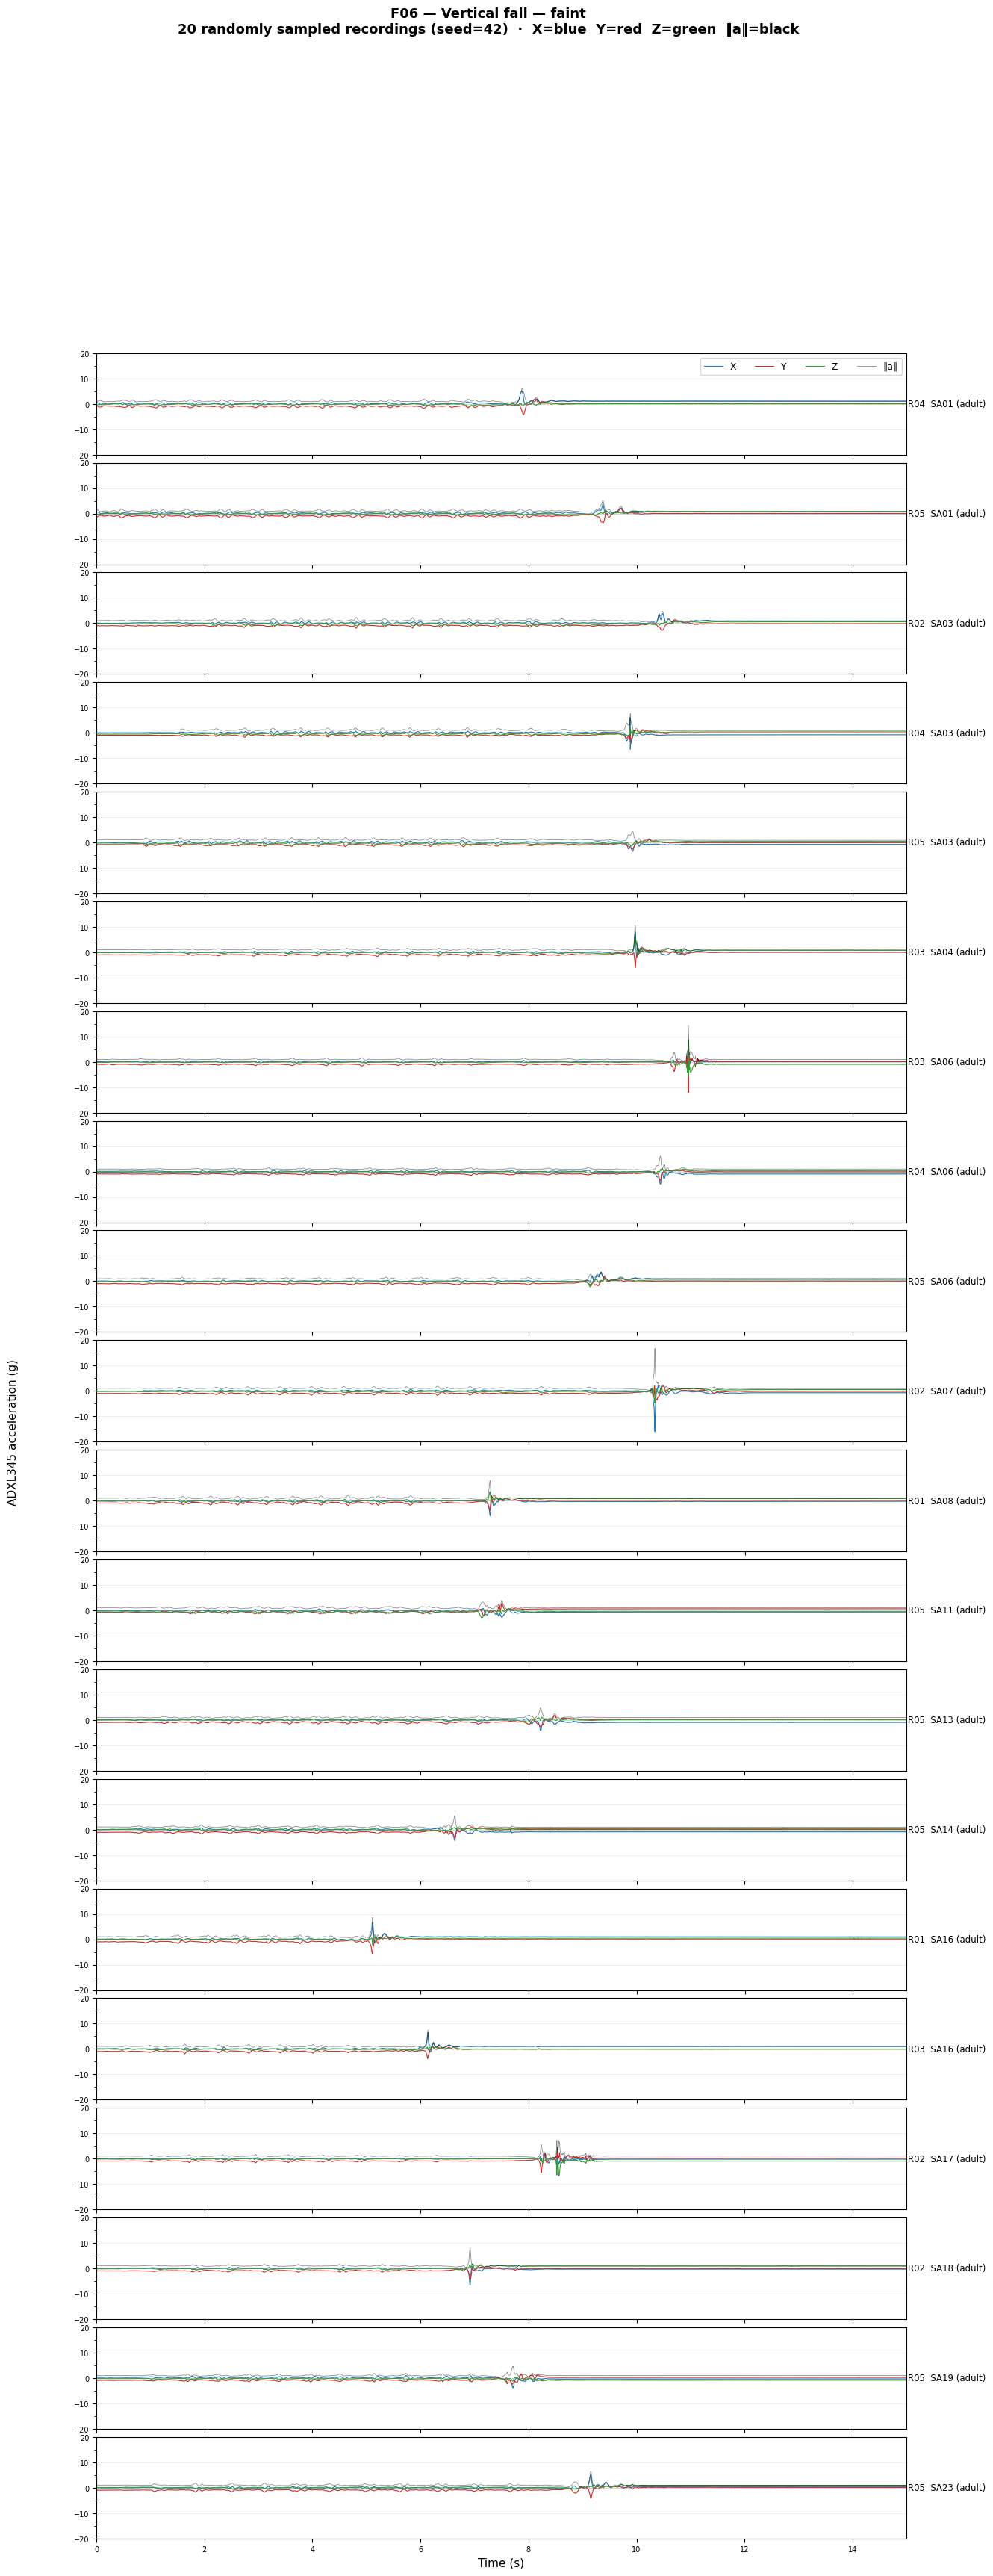

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F07.png


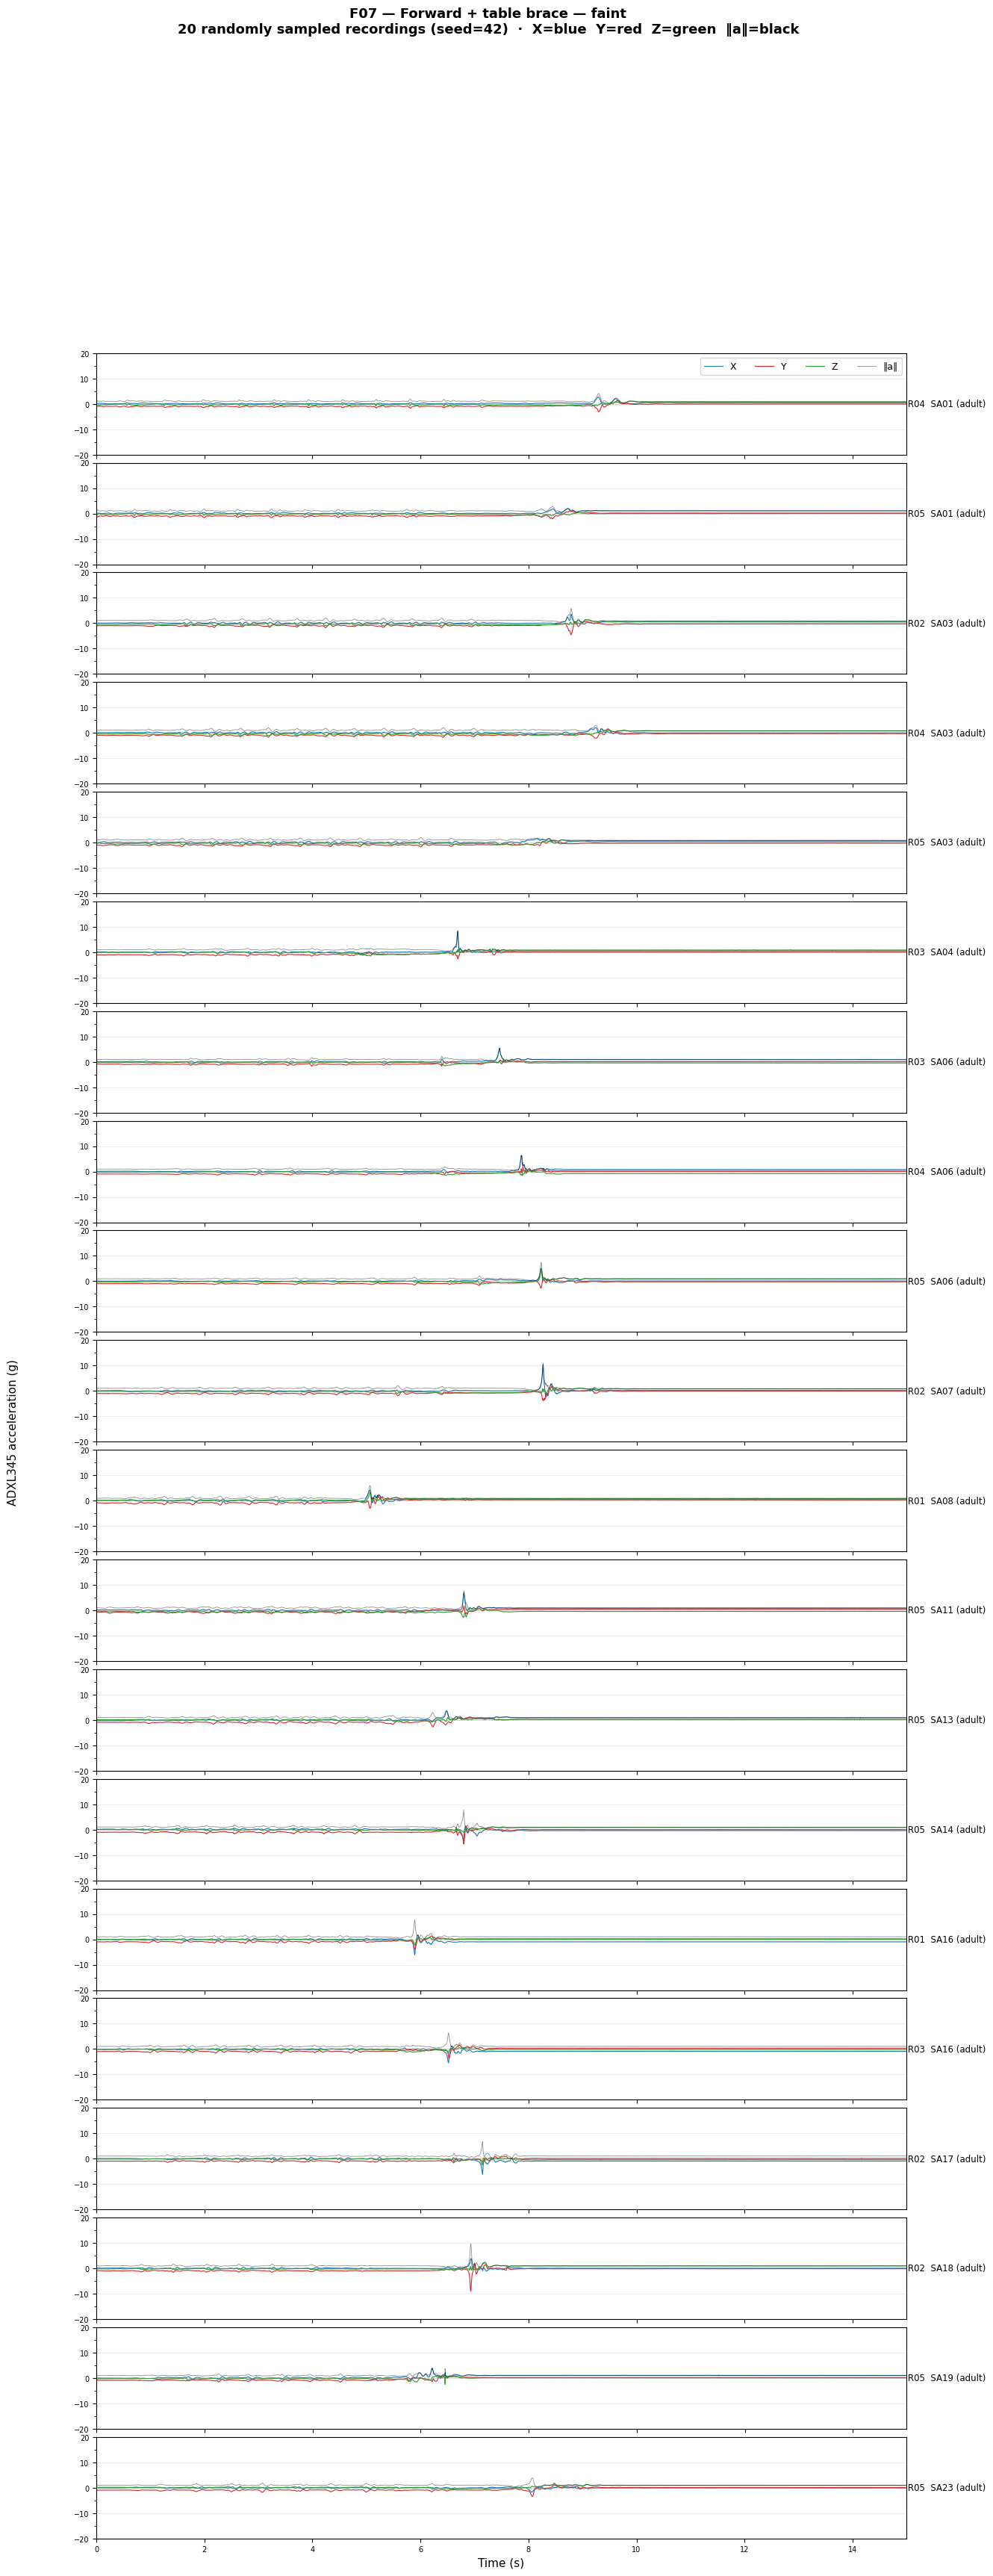

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F08.png


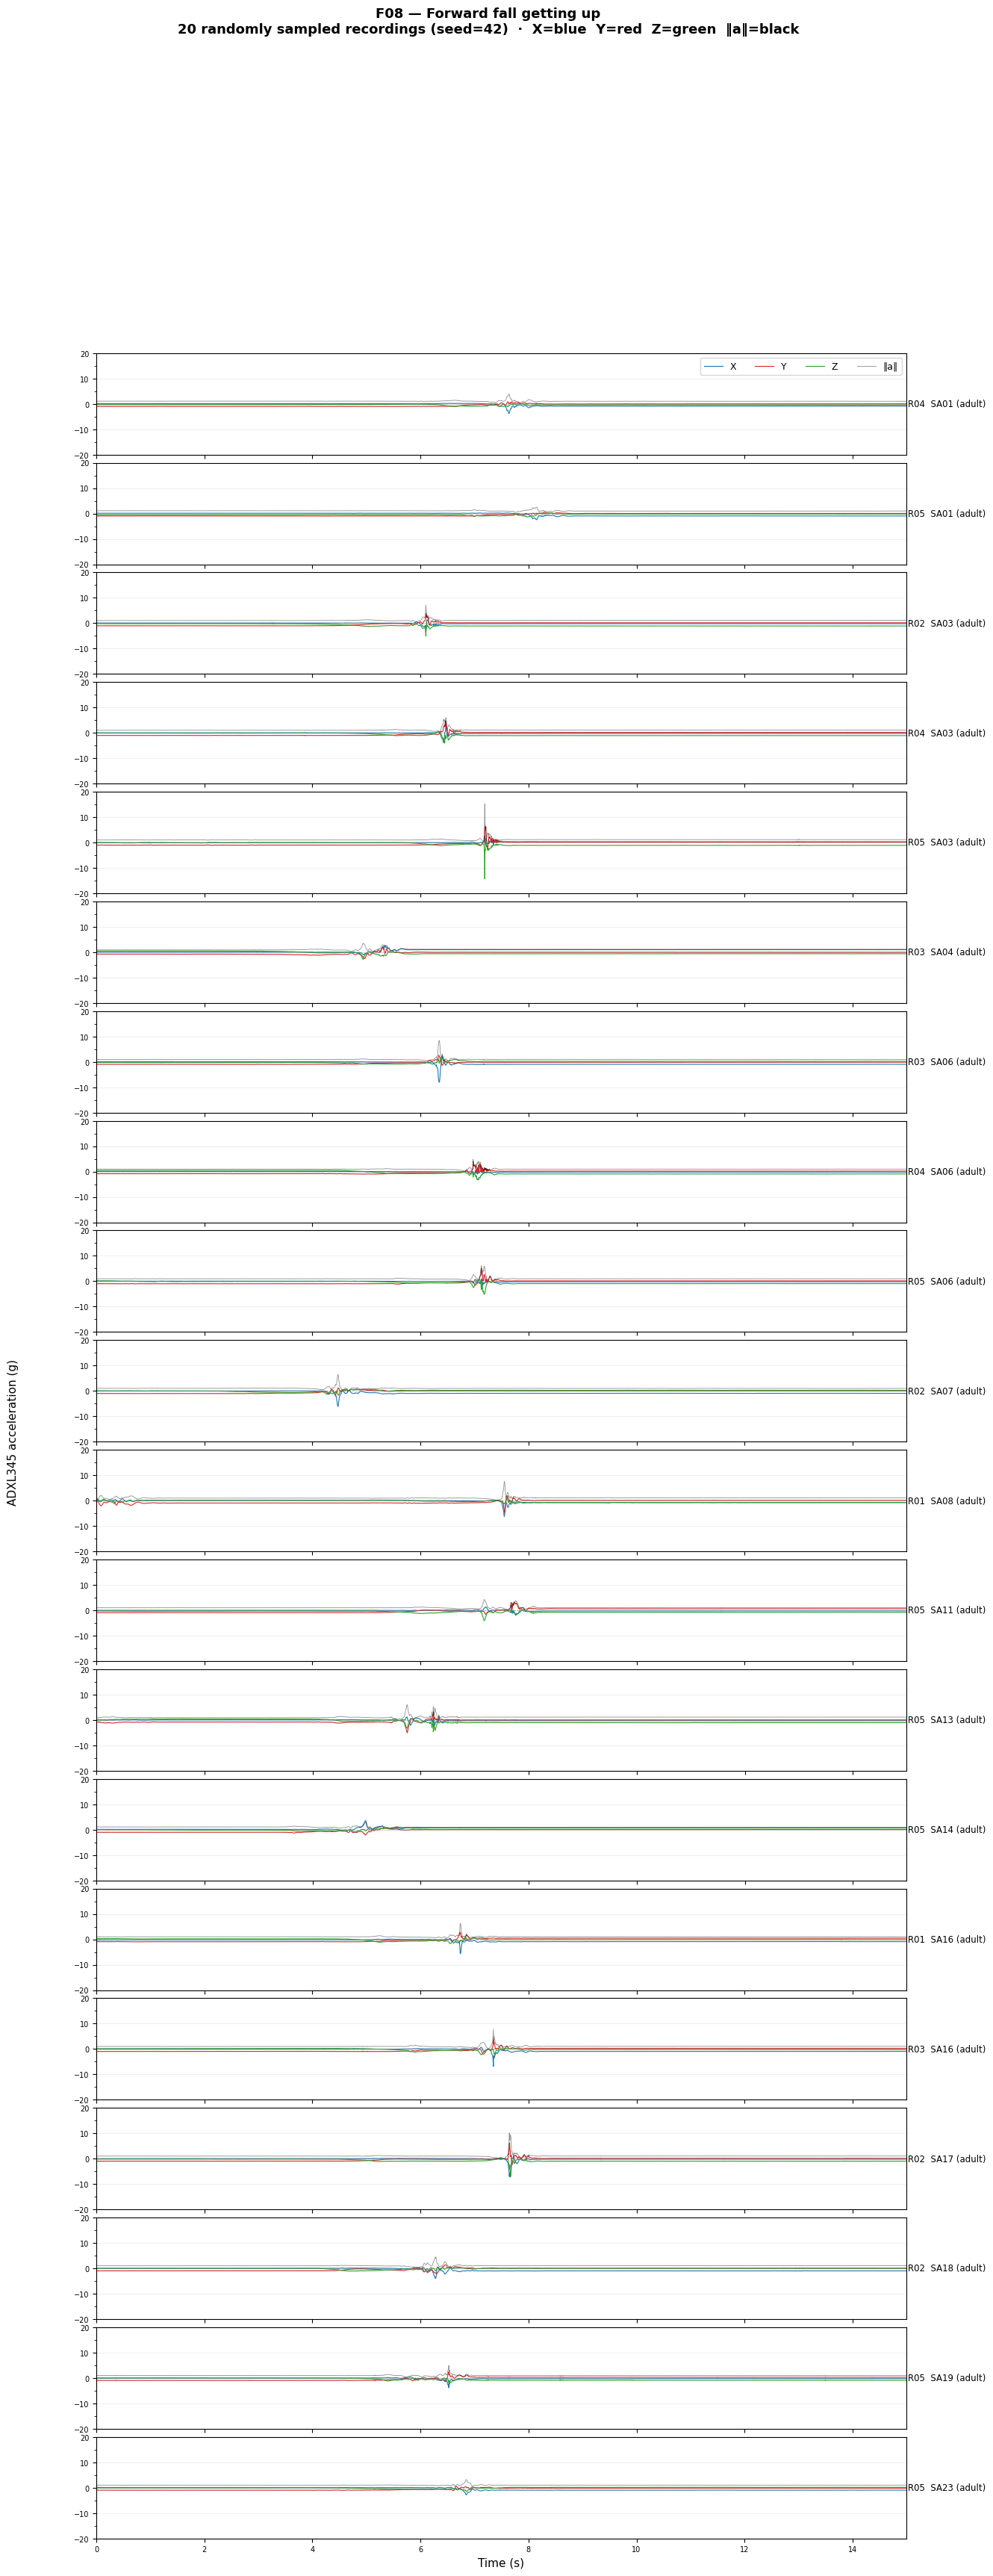

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F09.png


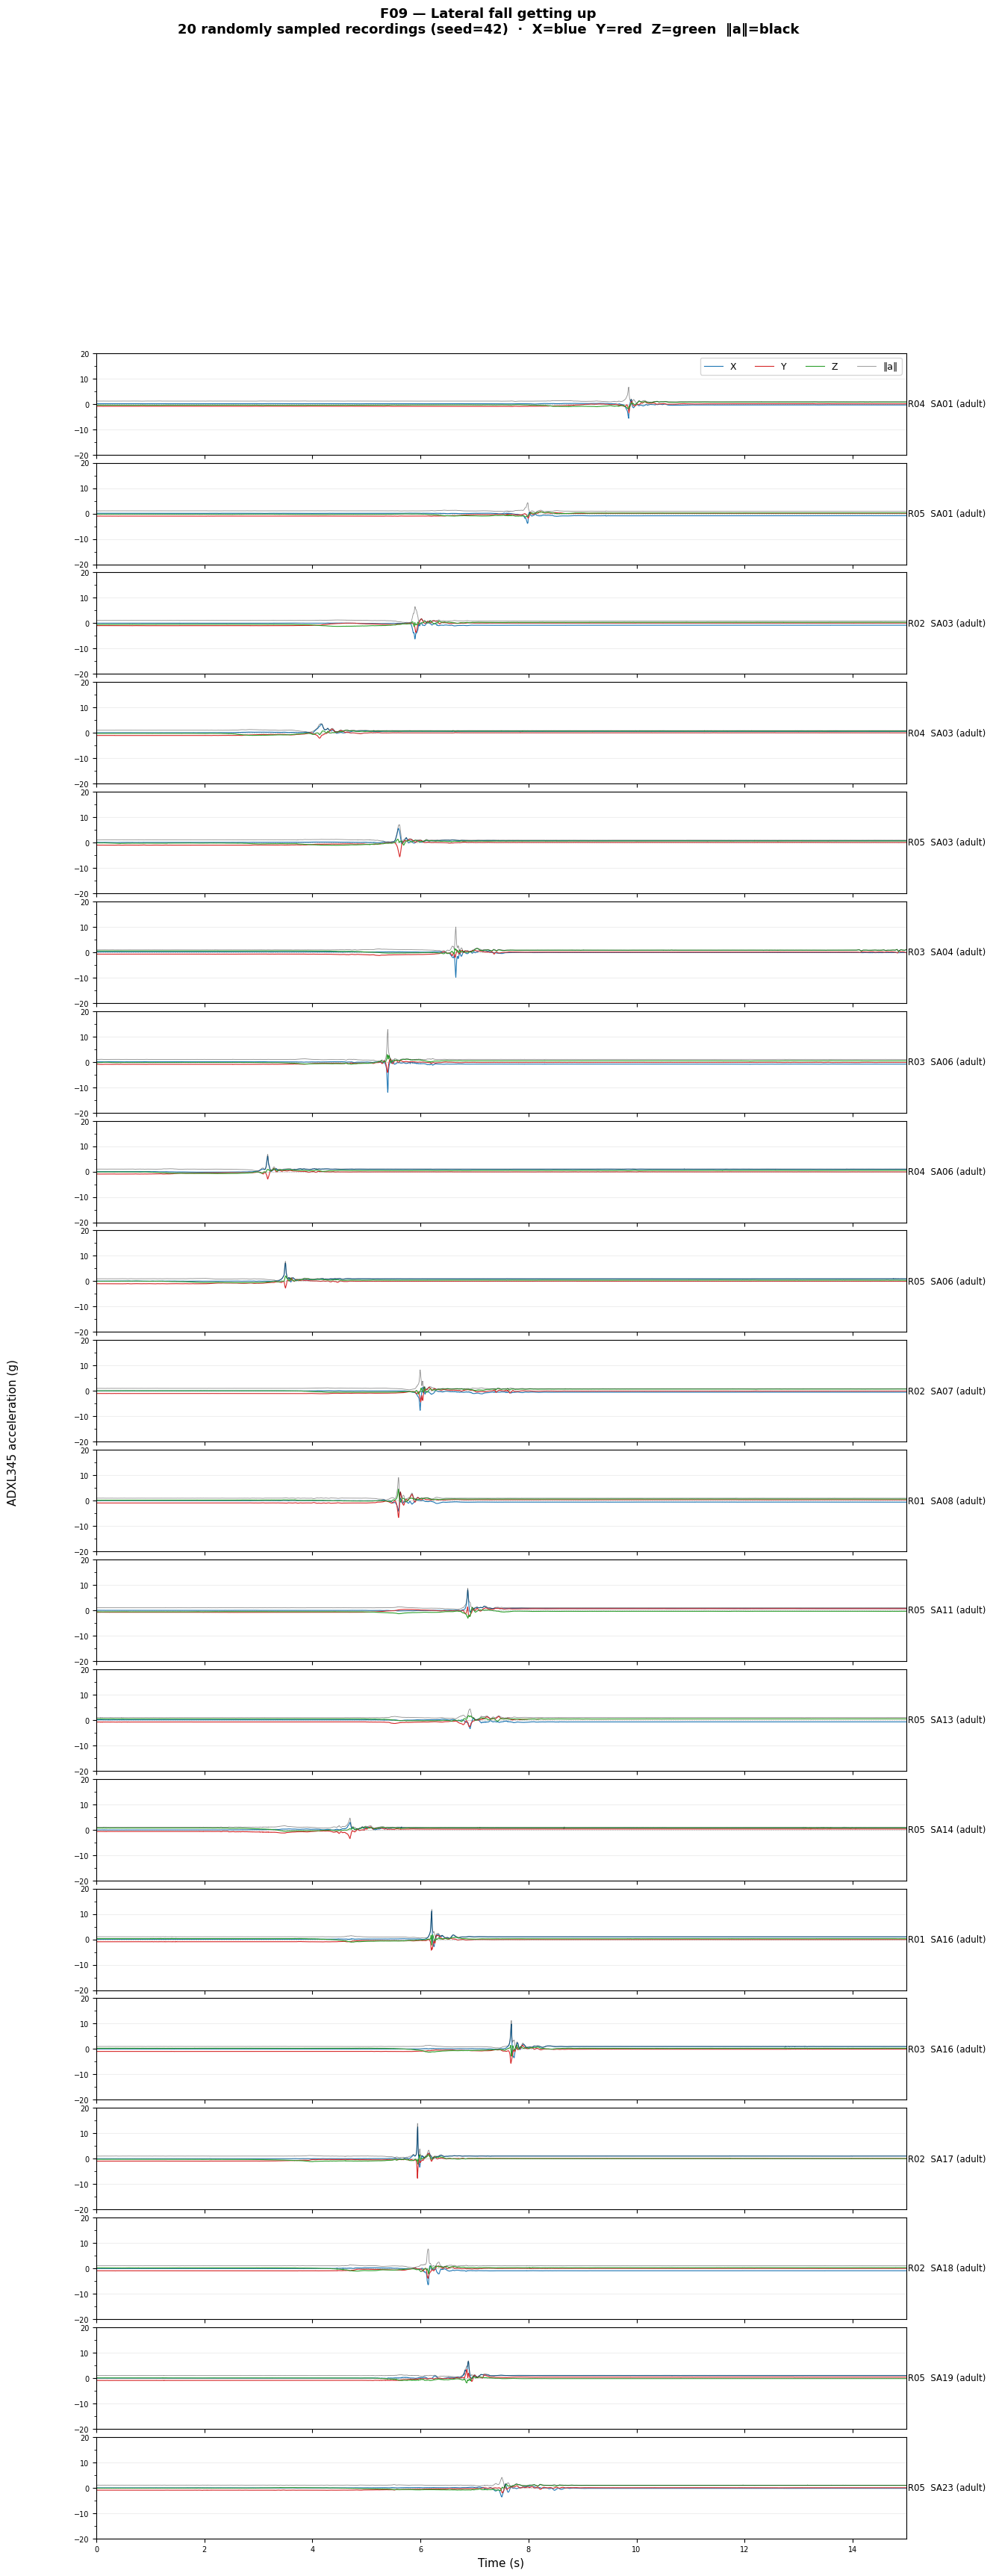

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F10.png


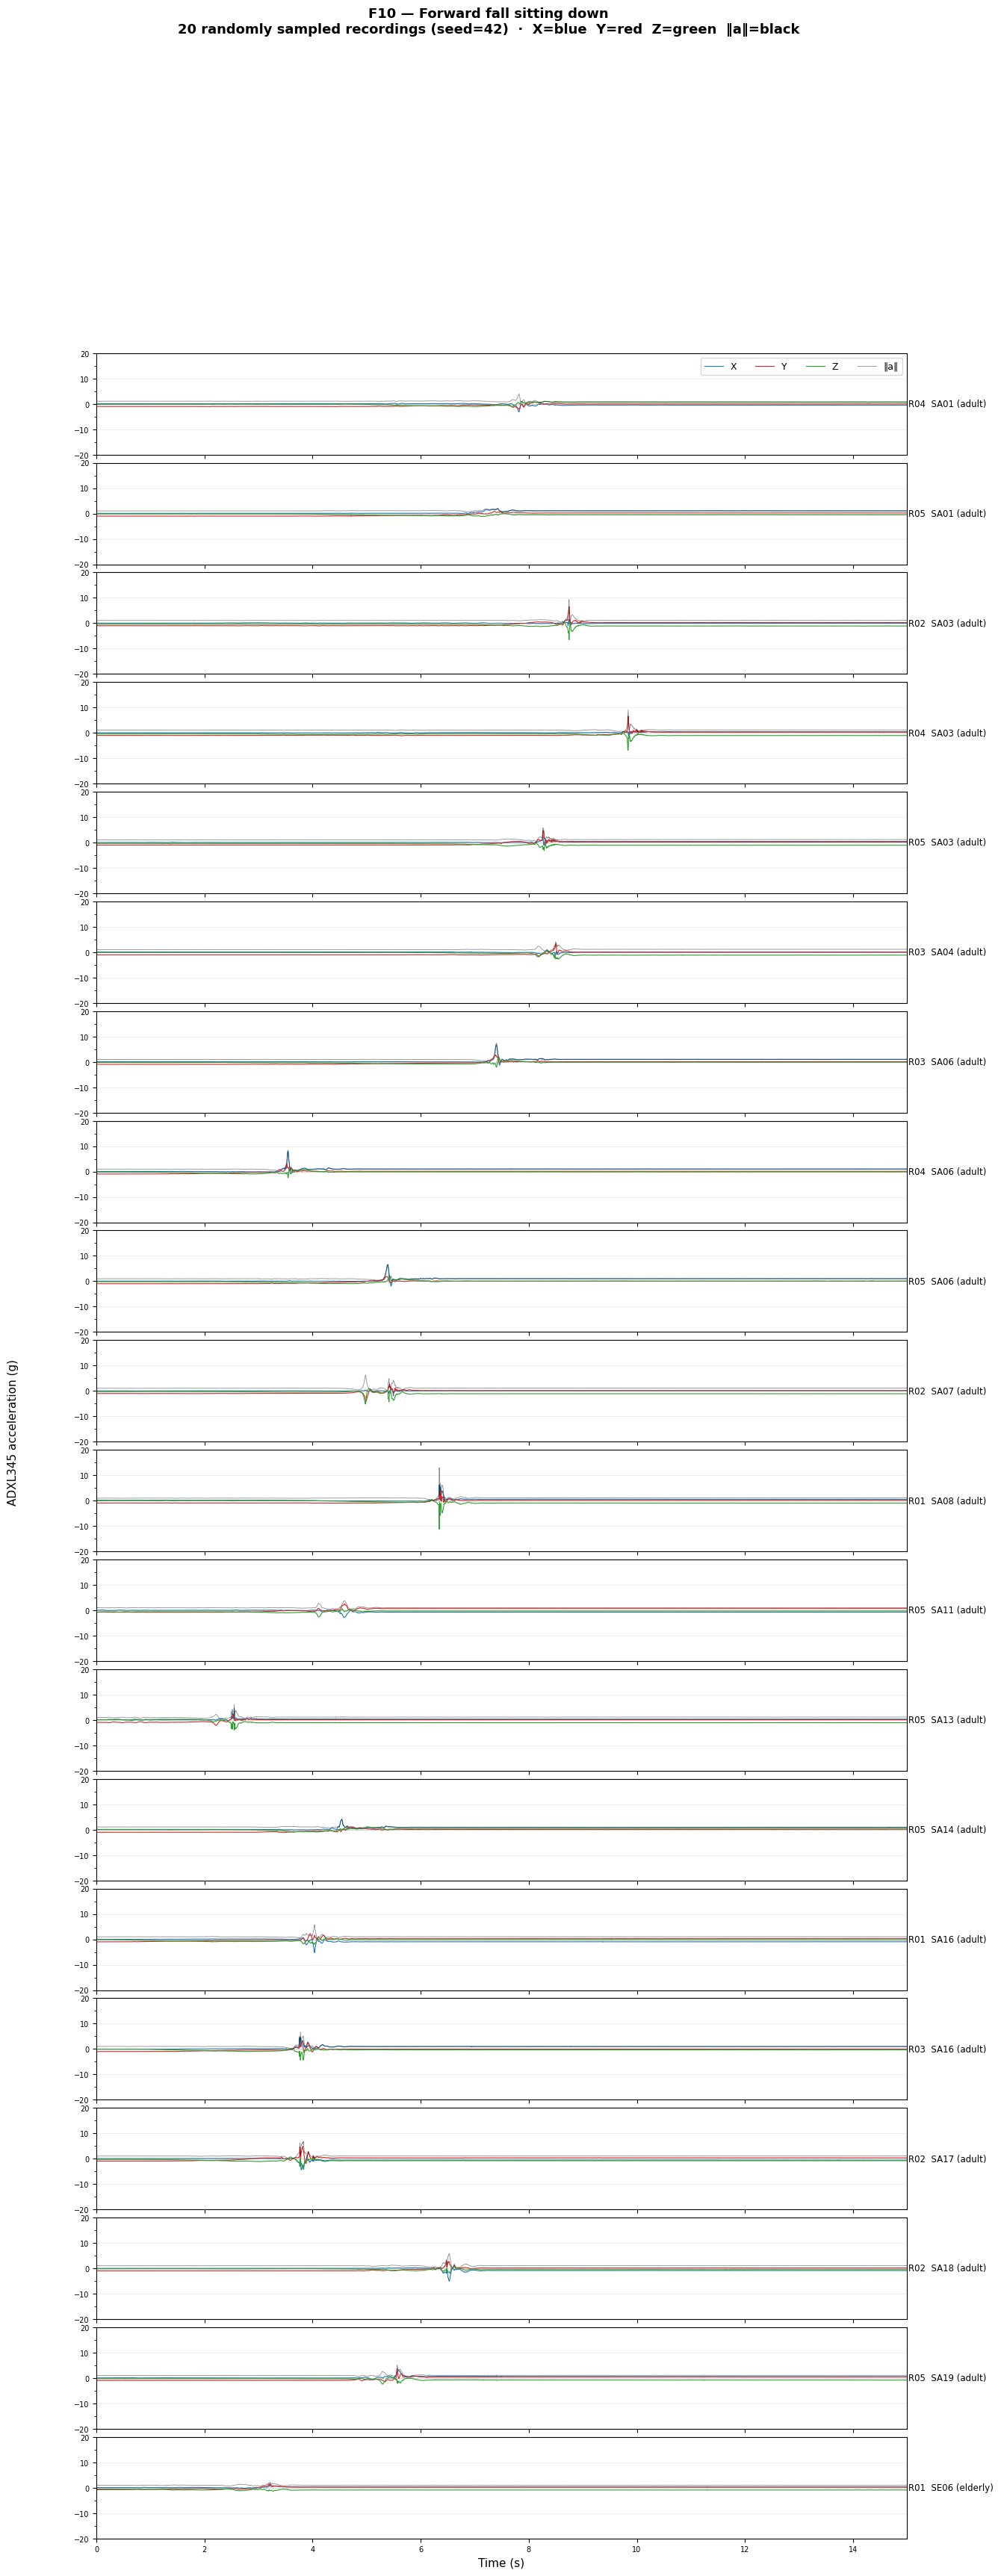

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F11.png


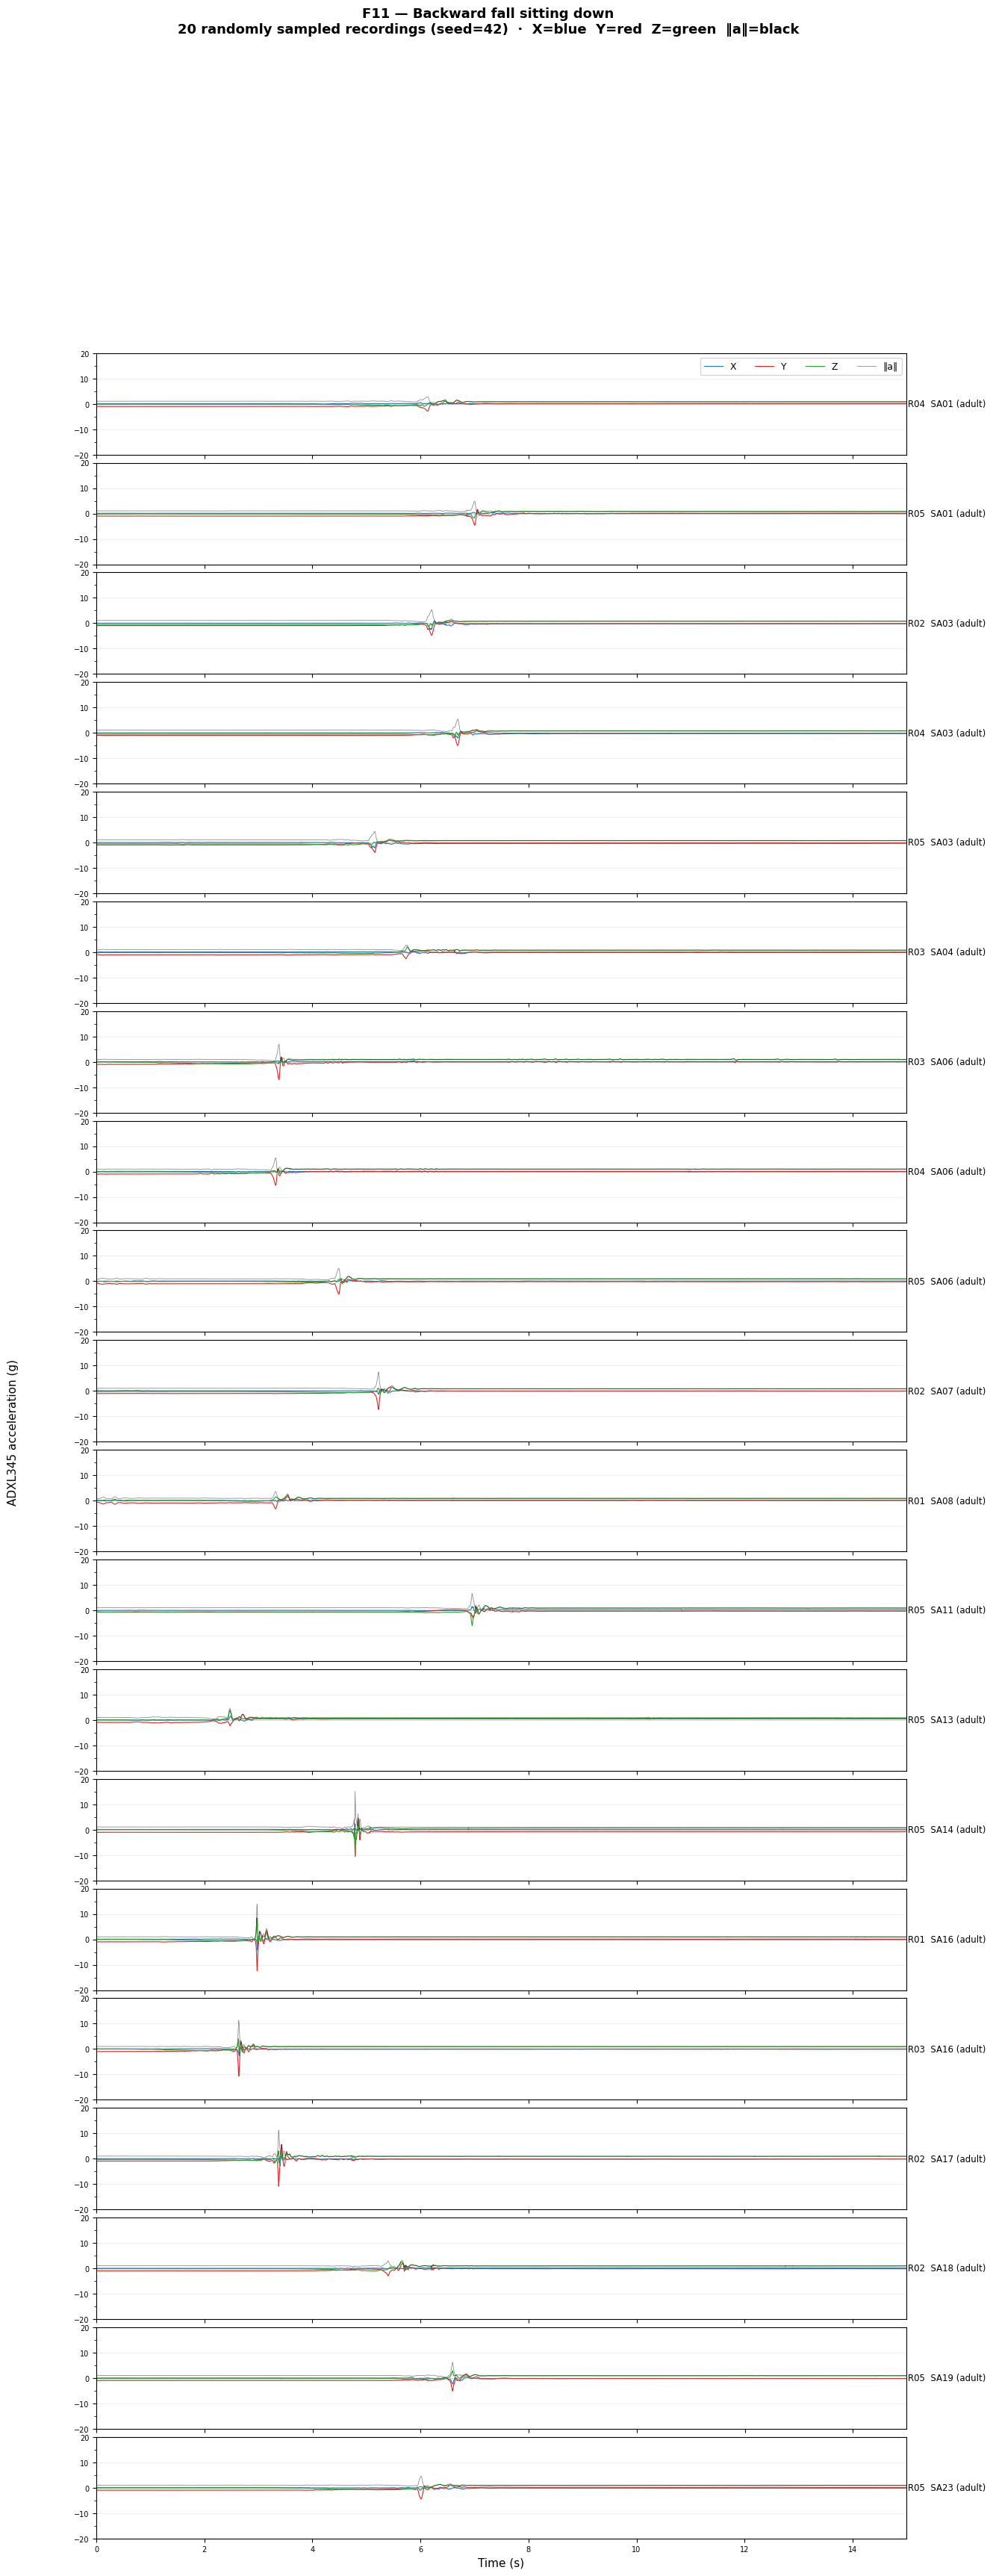

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F12.png


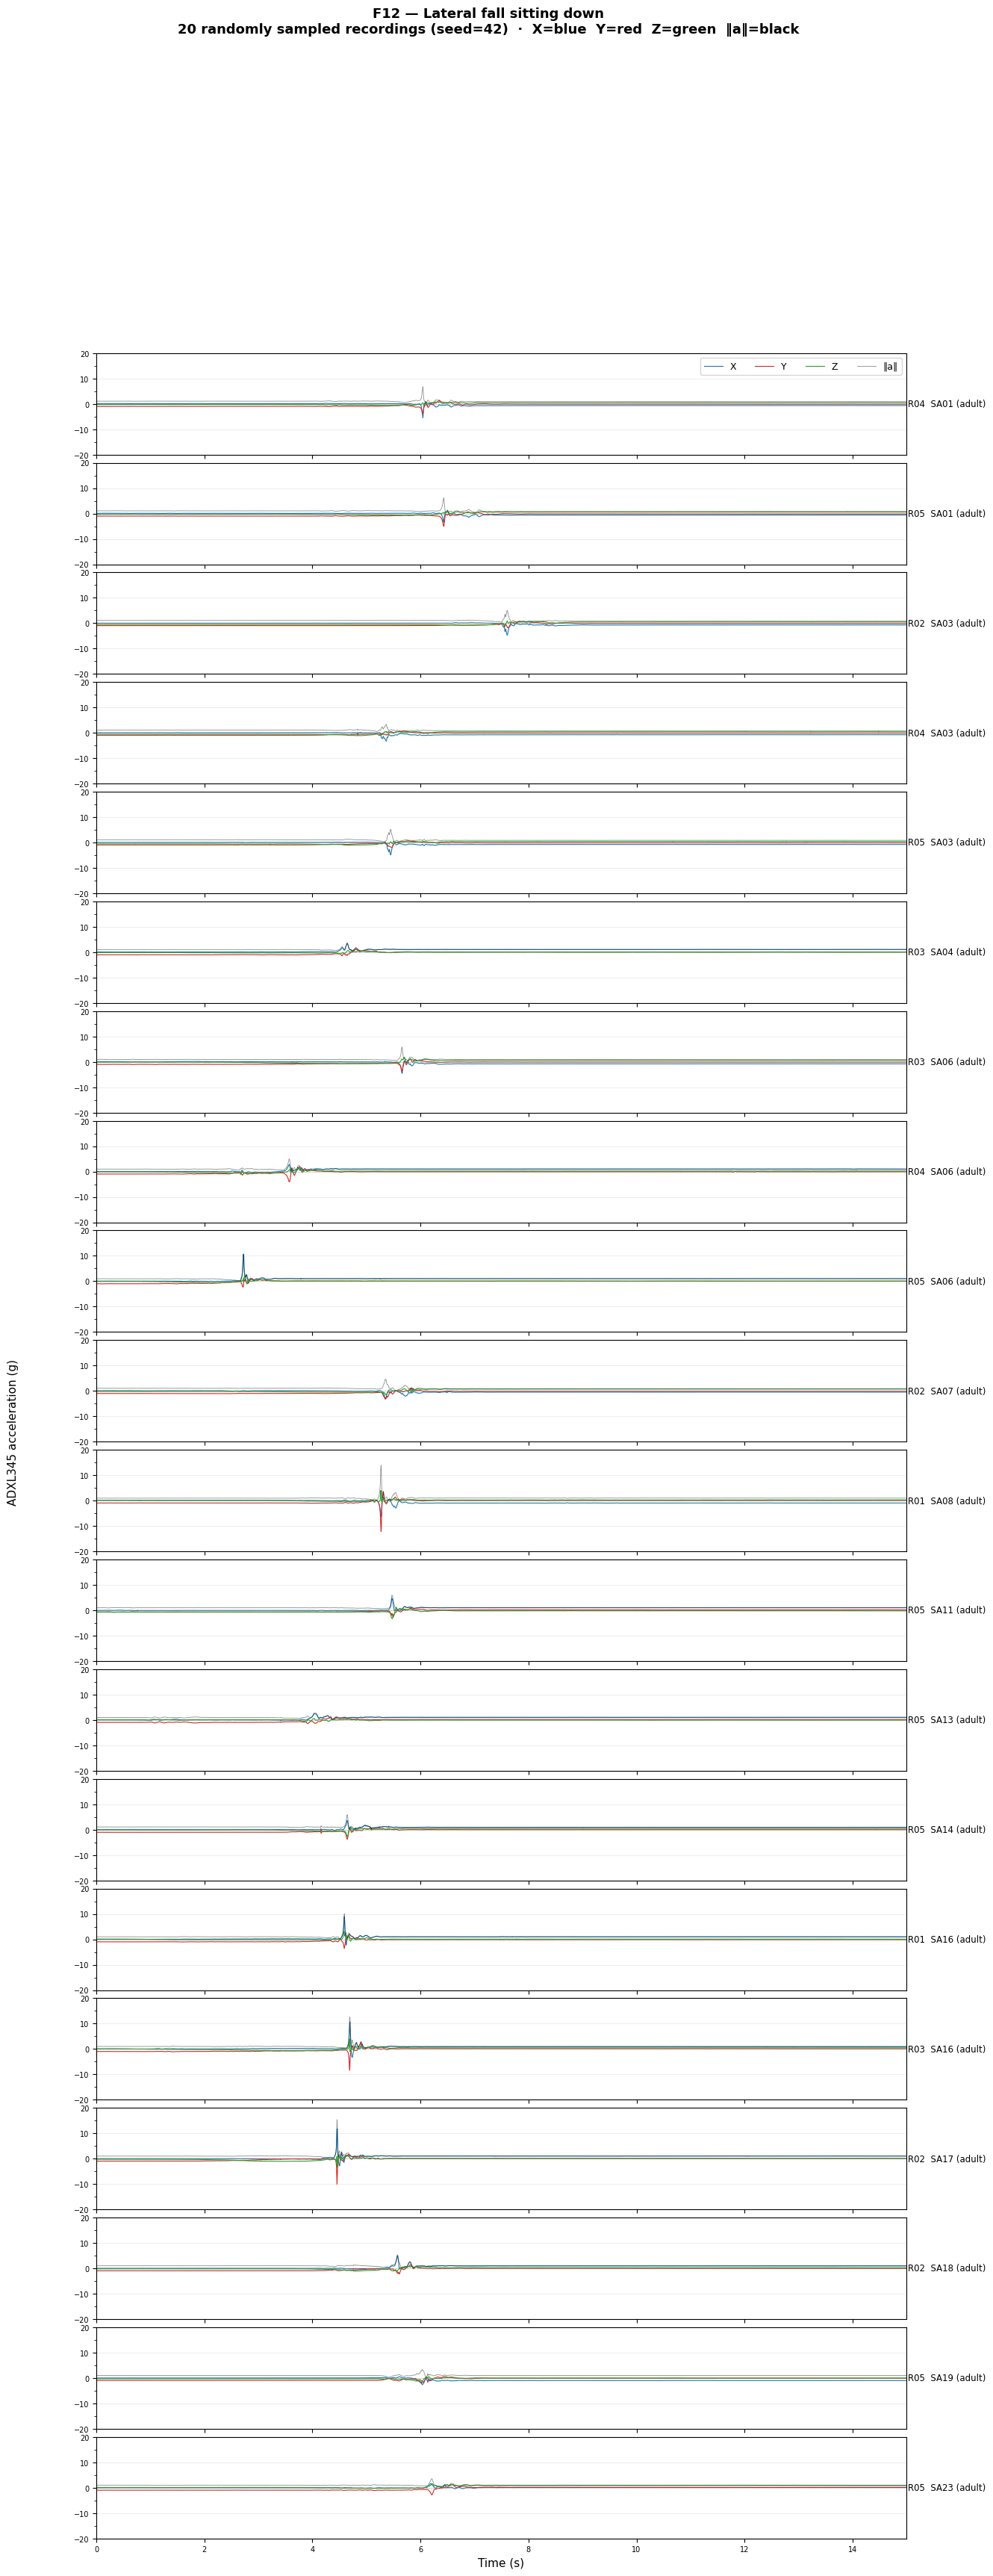

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F13.png


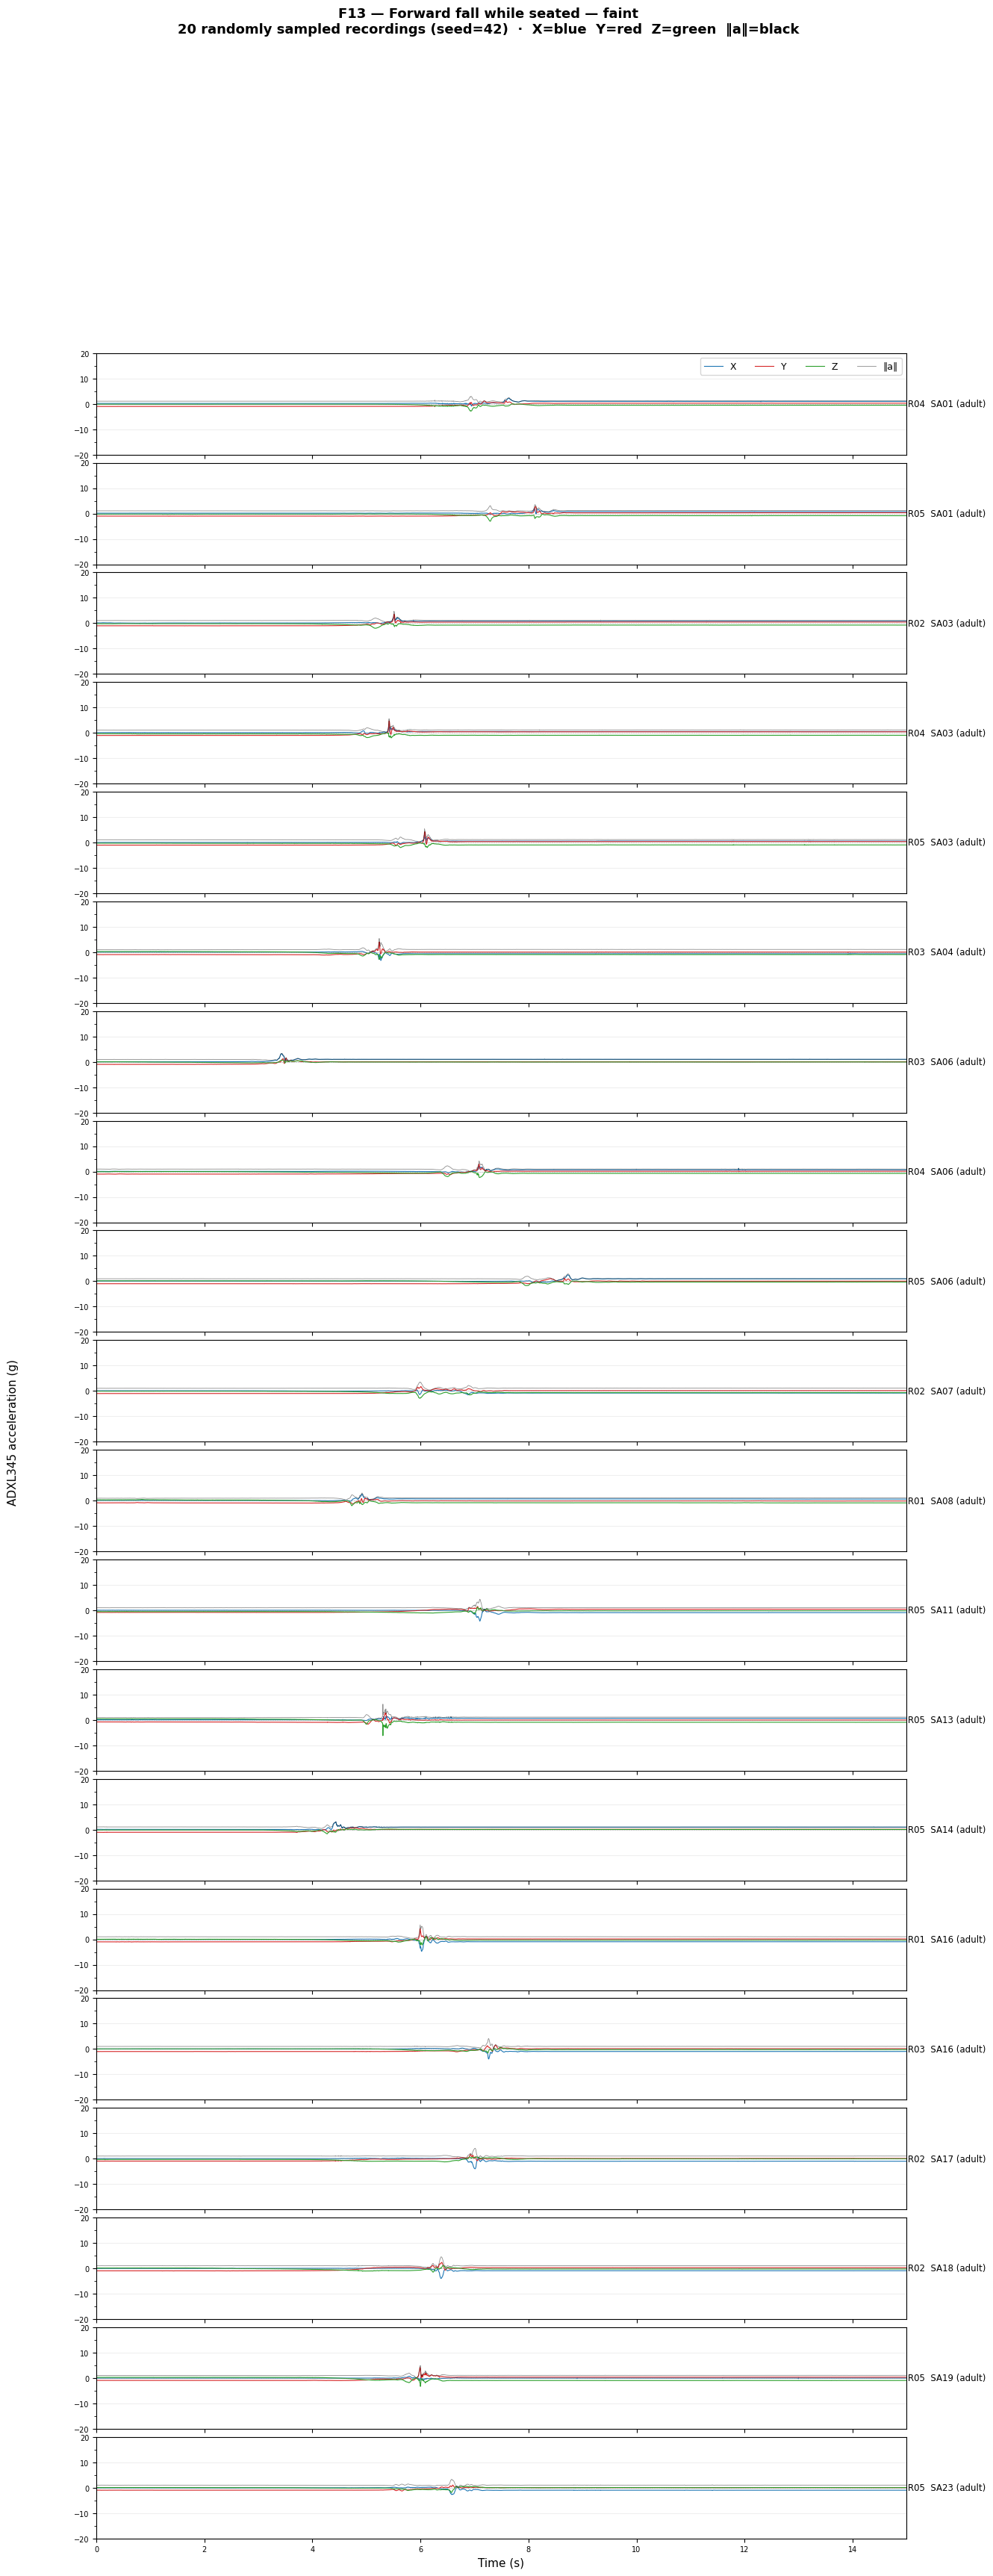

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F14.png


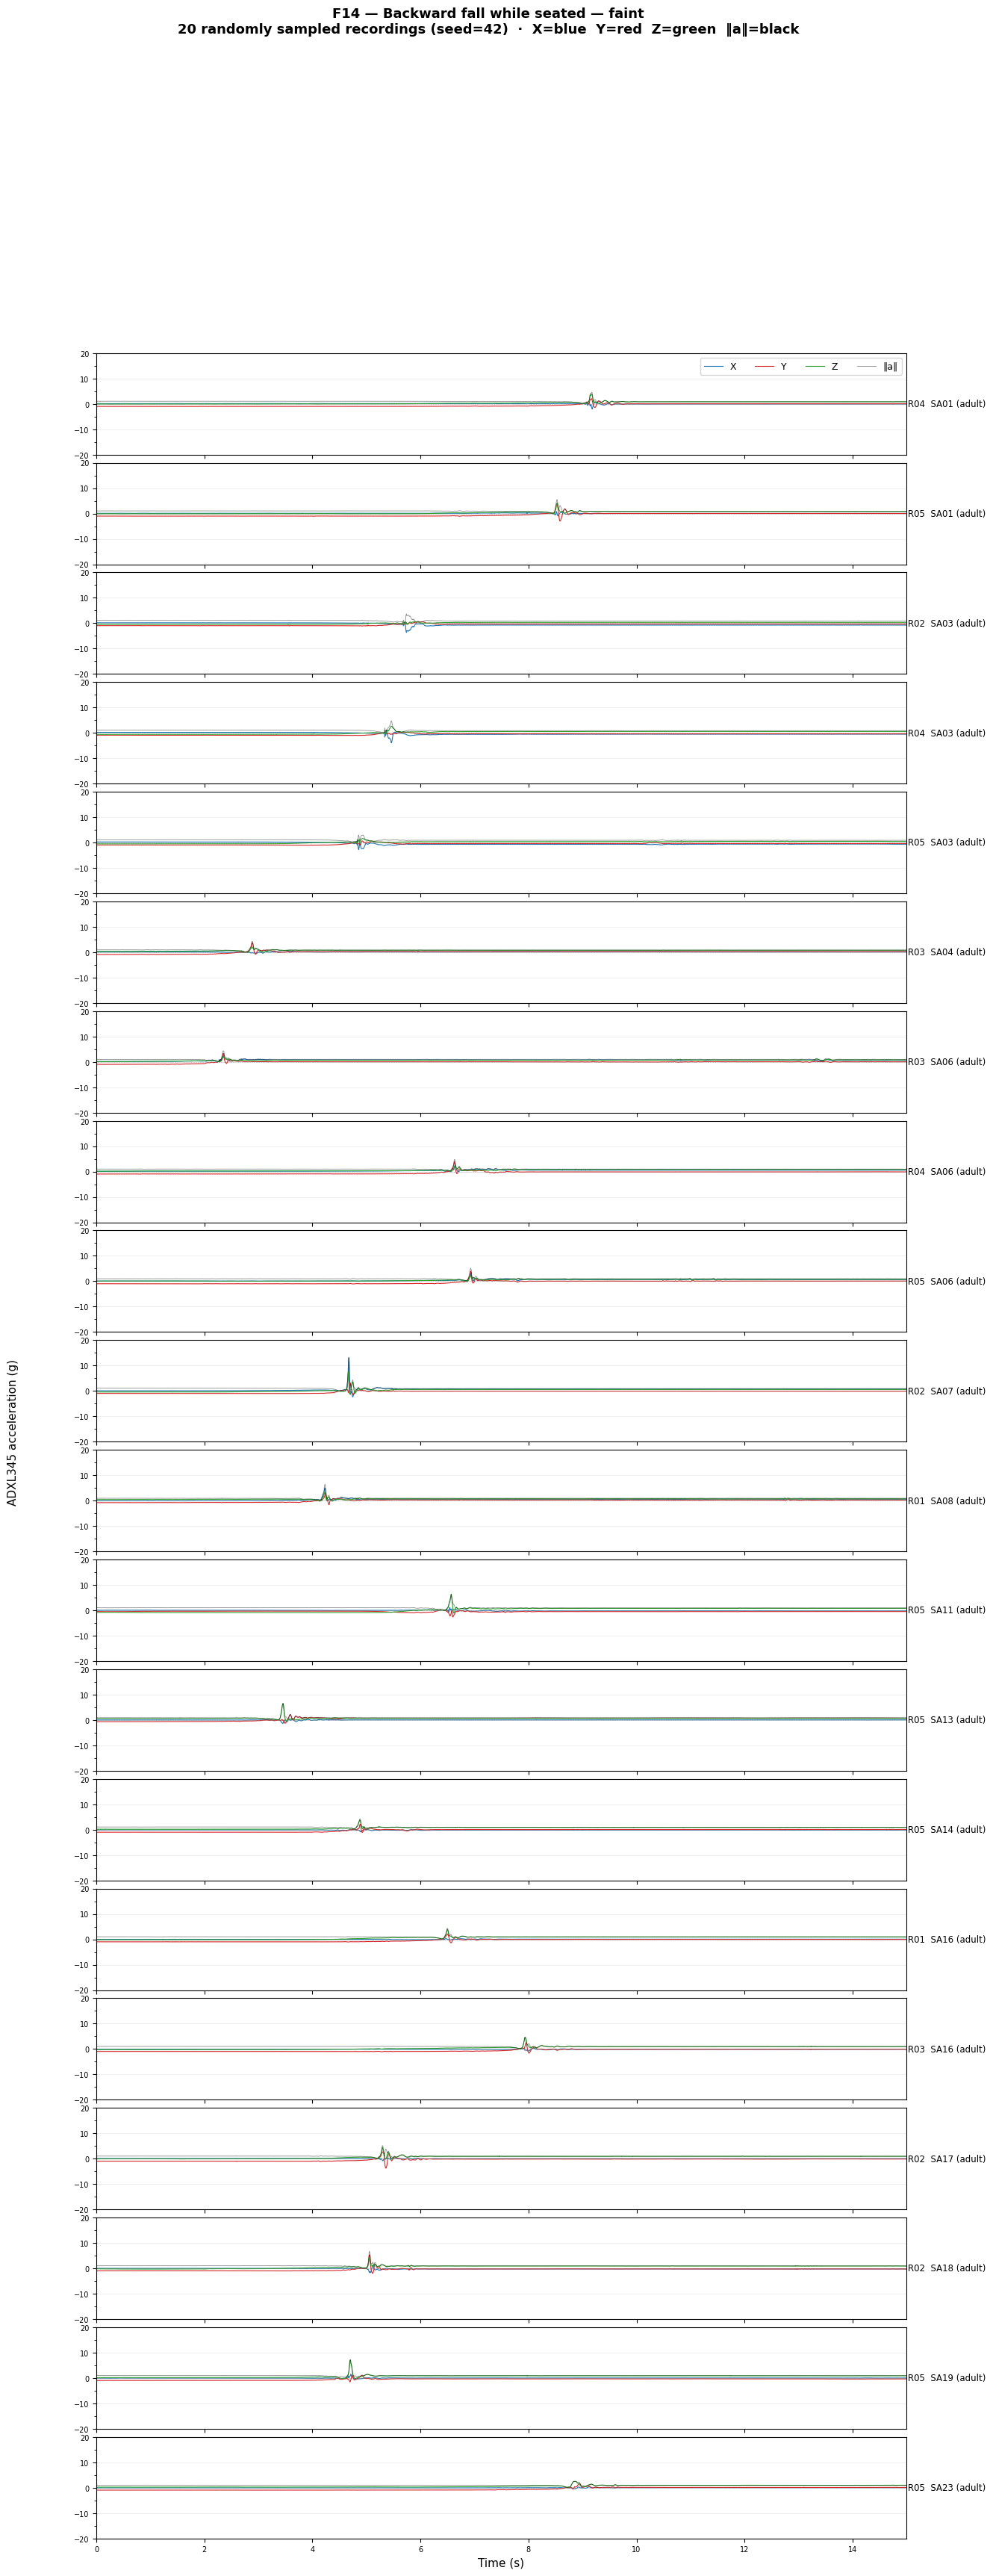

Saved /home/ubuntu/git/FD-CNN/signals_png/sisfall_gallery_F15.png


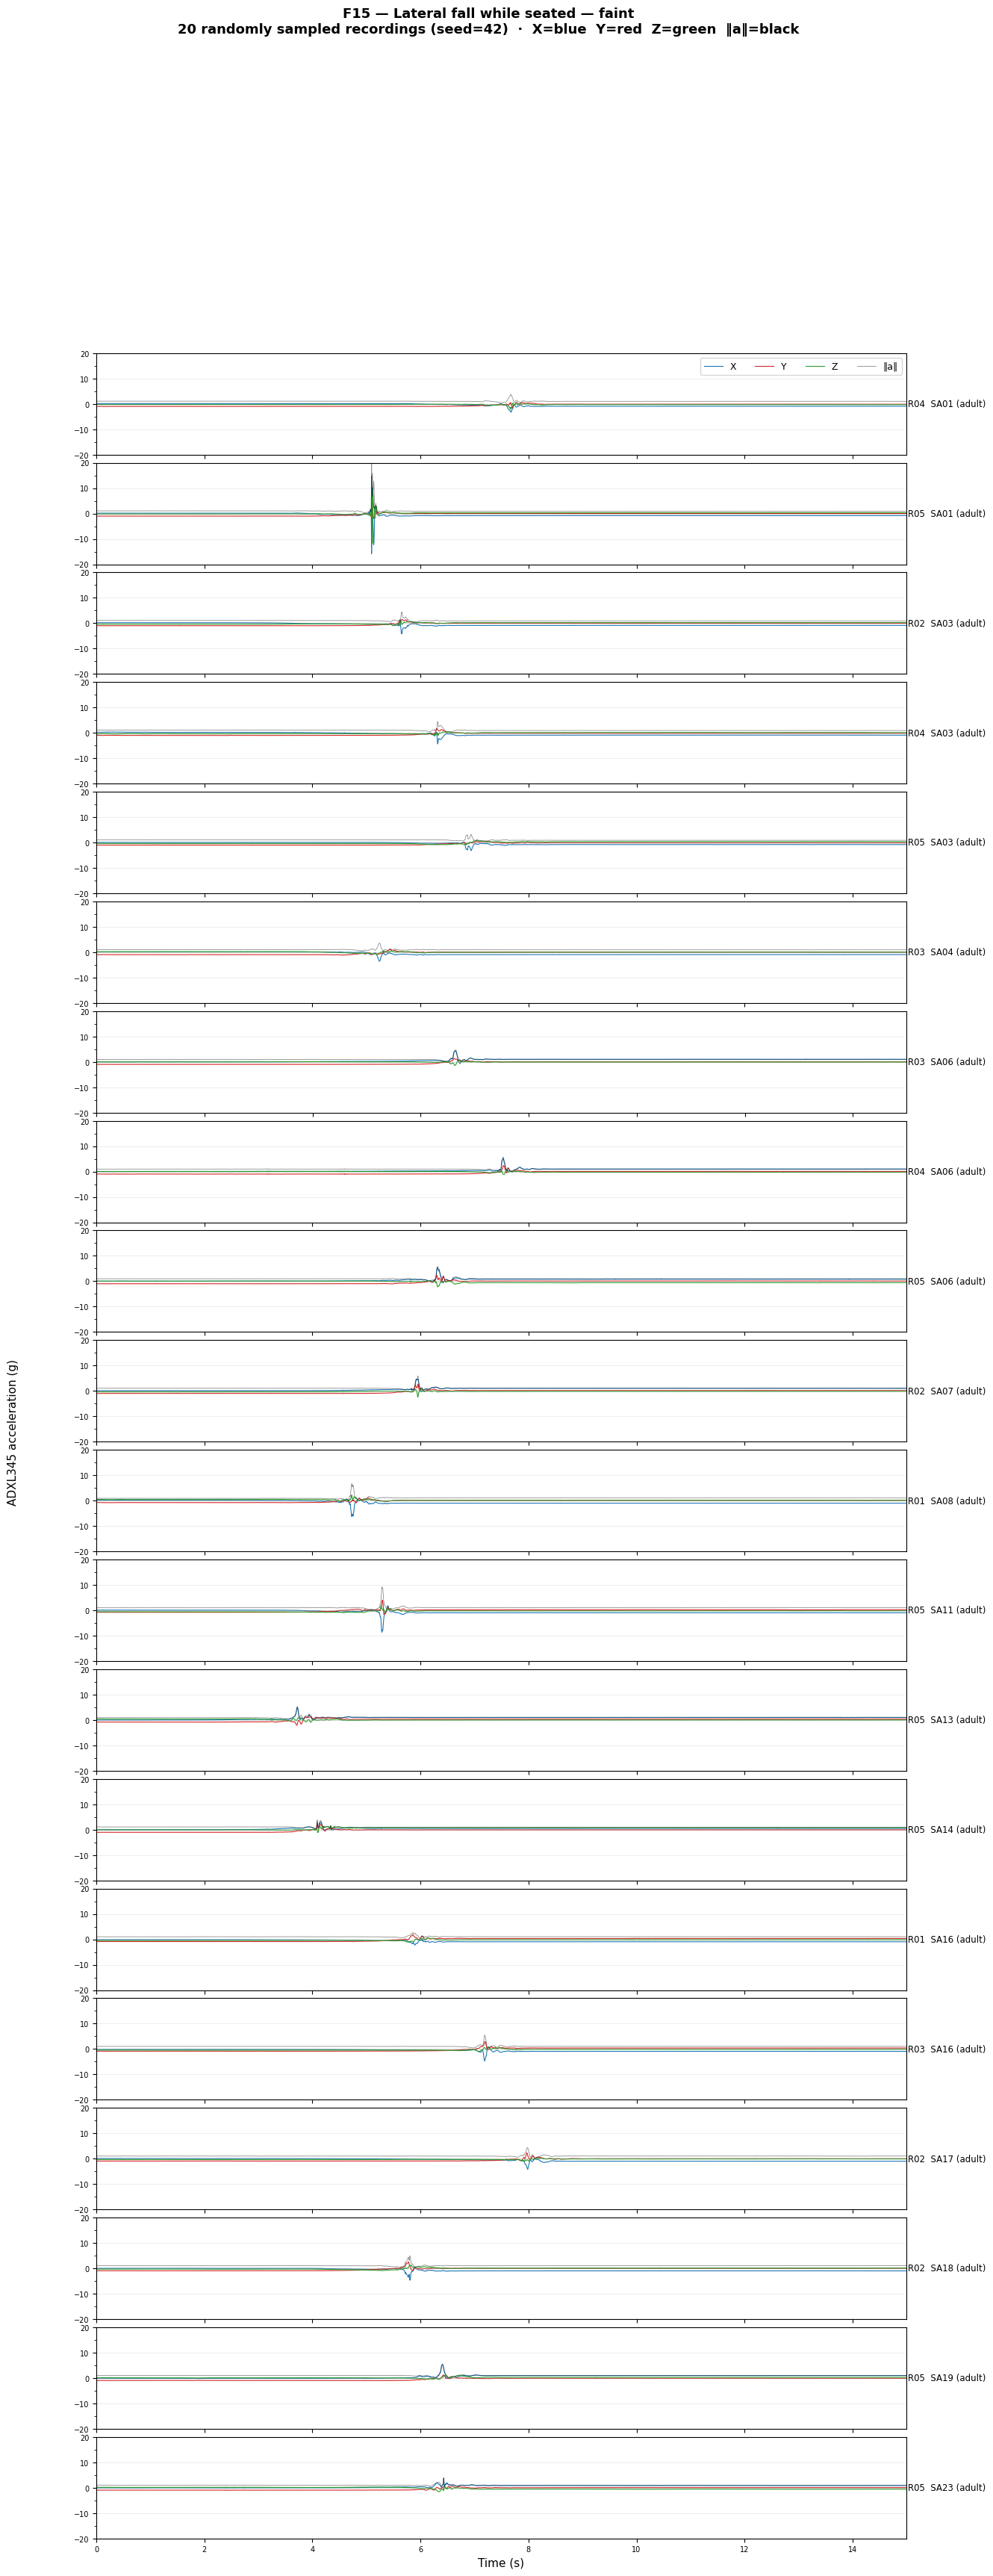

In [6]:
for code in sorted(files_by_code):
    plot_fall_class(code, files_by_code[code], n_plots=20, seed=42)

## 4-second peak-centred samples — F05 (Forward fall jogging)

Show a few `F05` recordings with the peak event aligned near the middle of a **4-second** window.
For consistency with the peak-centred training notebook, the signal is downsampled from **200 Hz to 100 Hz**, the ADXL345 magnitude `||a||` is used to find the peak, and a **400-sample** window is extracted around that peak.


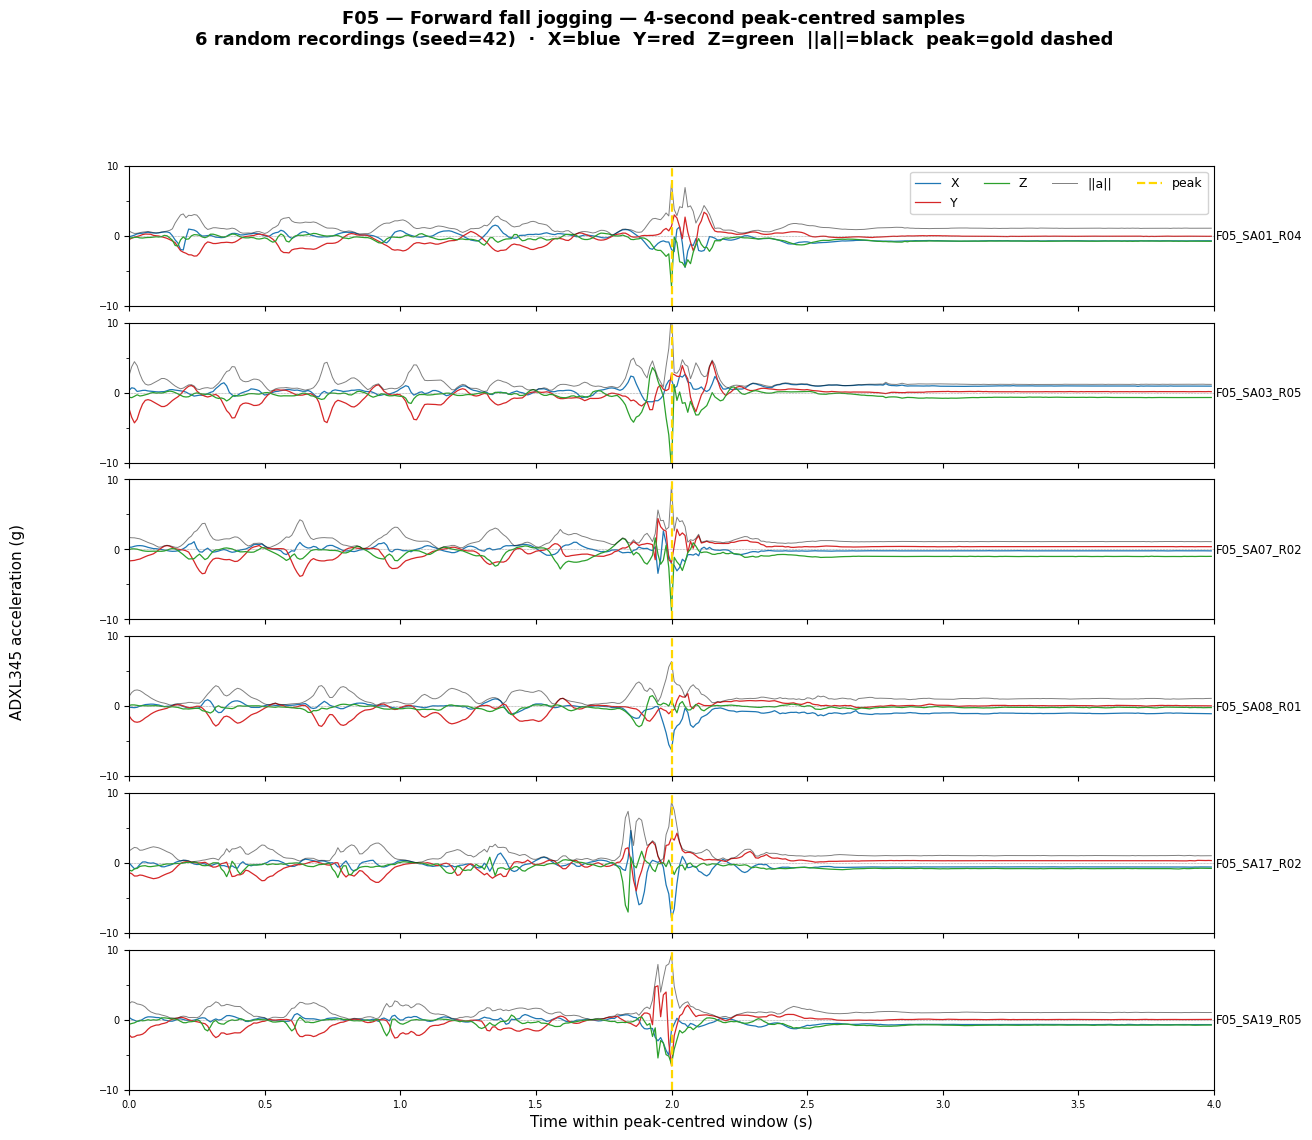

In [8]:
def extract_peak_centered_window(acc, window=400, downsample=2):
    """Downsample, find the acceleration peak, and extract a peak-centred window."""
    acc_ds = acc[::downsample]
    n = len(acc_ds)
    if n < window:
        return None, None, None

    magnitude = np.linalg.norm(acc_ds, axis=1)
    peak_idx = int(np.argmax(magnitude))
    start = max(0, min(peak_idx - window // 2, n - window))
    return acc_ds[start:start + window], peak_idx, start


FALL_CODE = 'F05'
N_SAMPLES = 6
WINDOW = 400           # 4 s at 100 Hz after downsampling
FS = 100.0
SEED = 42

f05_files = sorted(files_by_code[FALL_CODE])
rng = random.Random(SEED)
chosen = rng.sample(f05_files, min(N_SAMPLES, len(f05_files)))
chosen.sort()

fig, axes = plt.subplots(
    len(chosen), 1,
    figsize=(14, max(2.2, len(chosen) * 2.0)),
    gridspec_kw={'hspace': 0.12},
)
if len(chosen) == 1:
    axes = [axes]

for ax, fpath in zip(axes, chosen):
    acc = load_adxl(fpath)
    window_acc, peak_idx, start = extract_peak_centered_window(acc, window=WINDOW)
    if window_acc is None:
        ax.set_visible(False)
        continue

    t = np.arange(len(window_acc)) / FS
    magnitude = np.linalg.norm(window_acc, axis=1)
    peak_in_window = peak_idx - start

    for i, (axis_name, color) in enumerate(zip(['X', 'Y', 'Z'], AXIS_COLORS)):
        ax.plot(t, window_acc[:, i], color=color, linewidth=0.9,
                label=axis_name if ax is axes[0] else None)

    ax.plot(t, magnitude, color='black', linewidth=0.7, alpha=0.5,
            label='||a||' if ax is axes[0] else None)
    ax.axvline(peak_in_window / FS, color='gold', linewidth=1.6, linestyle='--',
               label='peak' if ax is axes[0] else None)
    ax.axhline(0, color='grey', linewidth=0.4, linestyle=':')
    ax.set_xlim(0, WINDOW / FS)
    ax.set_ylim(-10, 10)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))
    ax.grid(True, axis='y', alpha=0.2)
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=7)

    fname = os.path.basename(fpath).replace('.txt', '')
    ax.text(1.002, 0.5, fname, transform=ax.transAxes,
            va='center', ha='left', fontsize=8.5)

    if ax is not axes[-1]:
        ax.set_xticklabels([])

axes[-1].set_xlabel('Time within peak-centred window (s)', fontsize=11)
fig.text(0.04, 0.5, 'ADXL345 acceleration (g)', va='center',
         rotation='vertical', fontsize=11)
axes[0].legend(loc='upper right', fontsize=9, ncol=4, framealpha=0.85)

fig.suptitle(
    'F05 — Forward fall jogging — 4-second peak-centred samples\n'
    '6 random recordings (seed=42)  ·  X=blue  Y=red  Z=green  ||a||=black  peak=gold dashed',
    fontsize=13, fontweight='bold', y=1.01,
)
plt.show()